In [8]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.regularizers import l2

>In this notebook we train 3 models, Vanilla RNN, LSTM, GRU on a sequential dataset(airline-passengers dataset), and compare their performance. Also we analyse the effect of different sequence modeling components such as sequence length, hidden size, ...

## Preprocessing Dataset

>This dataset consists of 2 columns, one is the date and the other is the number of passengers, we partition our data into sequences of 12 months and try to predict the 13's month number of passengers.

In [2]:
# Load dataset

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])

# Create sequence data
data = df['Passengers'].values.reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [3]:

def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])      # A window of 12 months of passenger numbers
        y.append(data[i+seq_length])        # Next month's passenger number
    return np.array(X), np.array(y)

# Create sequences (using 12 months as sequence length)
seq_length = 12
X, y = create_sequences(data_scaled, seq_length)


In [4]:

def split_data(X, y):

    train_size = int(len(X) * 0.8)
    val_size = int(len(X) * 0.1)

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=train_size, shuffle=False)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=val_size, shuffle=False)

    return  X_train, y_train, X_val, y_val, X_test, y_test

In [5]:
# Split data

X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

In [6]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

## Vanilla RNN Model

In [9]:
# Vanilla RNN model

def create_vanilla_rnn(seq_length, hidden_size=64, num_layers=1, dropout_between_layers=0.0, recurrent_dropout=0.0, bidirectional=False):

    model = Sequential()

    if num_layers == 1:
        # Single layer
        rnn_layer = SimpleRNN(hidden_size,
                             activation='tanh',
                             input_shape=(seq_length, 1),
                             return_sequences=False,
                             dropout=recurrent_dropout,
                             kernel_regularizer=l2(0.001),
                             recurrent_regularizer=l2(0.001))

        if bidirectional:
            model.add(Bidirectional(rnn_layer))
        else:
            model.add(rnn_layer)
    else:
        # First layer
        rnn_layer_1 = SimpleRNN(hidden_size,
                               activation='tanh',
                               input_shape=(seq_length, 1),
                               return_sequences=True,
                               dropout=recurrent_dropout,
                               kernel_regularizer=l2(0.001),
                               recurrent_regularizer=l2(0.001))

        if bidirectional:
            model.add(Bidirectional(rnn_layer_1))
        else:
            model.add(rnn_layer_1)

        # Middle layers with dropout between them
        for i in range(num_layers - 2):
            if dropout_between_layers > 0:
                model.add(Dropout(dropout_between_layers))

            rnn_layer_mid = SimpleRNN(hidden_size,
                                     activation='tanh',
                                     return_sequences=True,
                                     dropout=recurrent_dropout,
                                     kernel_regularizer=l2(0.001),
                                     recurrent_regularizer=l2(0.001))

            if bidirectional:
                model.add(Bidirectional(rnn_layer_mid))
            else:
                model.add(rnn_layer_mid)

        # Last layer
        if dropout_between_layers > 0 and num_layers > 1:
            model.add(Dropout(dropout_between_layers))

        rnn_layer_last = SimpleRNN(hidden_size,
                                  activation='tanh',
                                  return_sequences=False,
                                  dropout=recurrent_dropout,
                                  kernel_regularizer=l2(0.001),
                                  recurrent_regularizer=l2(0.001))

        if bidirectional:
            model.add(Bidirectional(rnn_layer_last))
        else:
            model.add(rnn_layer_last)

    # Output layers
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    return model

vanilla_rnn = create_vanilla_rnn(seq_length)
vanilla_rnn.summary()

# Train Vanilla RNN
print("\nTraining Vanilla RNN...")
history_vrnn = vanilla_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)


Training Vanilla RNN...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.1390 - mae: 0.1320 - val_loss: 0.1330 - val_mae: 0.1245
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1218 - mae: 0.0928 - val_loss: 0.1625 - val_mae: 0.2067
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1207 - mae: 0.0859 - val_loss: 0.1160 - val_mae: 0.0839
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1182 - mae: 0.0887 - val_loss: 0.1126 - val_mae: 0.0774
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1148 - mae: 0.0732 - val_loss: 0.1172 - val_mae: 0.0954
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1085 - mae: 0.0619 - val_loss: 0.1236 - val_mae: 0.1257
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1071 - mae: 0.0580 - val_loss: 0.1103 - val_mae: 0.0781
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1074 - mae: 0.0603 - val_loss: 0.1050 - val_mae: 0.0555
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

## LSTM Model

In [10]:
# LSTM model

def create_lstm(seq_length, hidden_size=64, num_layers=1, dropout_between_layers=0.0, recurrent_dropout=0.0, bidirectional=False):

    model = Sequential()

    if num_layers == 1:
        # Single layer
        lstm_layer = LSTM(hidden_size,
                         activation='tanh',
                         input_shape=(seq_length, 1),
                         return_sequences=False,
                         dropout=recurrent_dropout,
                         kernel_regularizer=l2(0.001),
                         recurrent_regularizer=l2(0.001))

        if bidirectional:
            model.add(Bidirectional(lstm_layer))
        else:
            model.add(lstm_layer)
    else:
        # First layer
        lstm_layer_1 = LSTM(hidden_size,
                           activation='tanh',
                           input_shape=(seq_length, 1),
                           return_sequences=True,
                           dropout=recurrent_dropout,
                           kernel_regularizer=l2(0.001),
                           recurrent_regularizer=l2(0.001))

        if bidirectional:
            model.add(Bidirectional(lstm_layer_1))
        else:
            model.add(lstm_layer_1)

        # Middle layers with dropout between them
        for i in range(num_layers - 2):
            if dropout_between_layers > 0:
                model.add(Dropout(dropout_between_layers))

            lstm_layer_mid = LSTM(hidden_size,
                                 activation='tanh',
                                 return_sequences=True,
                                 dropout=recurrent_dropout,
                                 kernel_regularizer=l2(0.001),
                                 recurrent_regularizer=l2(0.001))

            if bidirectional:
                model.add(Bidirectional(lstm_layer_mid))
            else:
                model.add(lstm_layer_mid)

        # Last layer
        if dropout_between_layers > 0 and num_layers > 1:
            model.add(Dropout(dropout_between_layers))

        lstm_layer_last = LSTM(hidden_size,
                              activation='tanh',
                              return_sequences=False,
                              dropout=recurrent_dropout,
                              kernel_regularizer=l2(0.001),
                              recurrent_regularizer=l2(0.001))

        if bidirectional:
            model.add(Bidirectional(lstm_layer_last))
        else:
            model.add(lstm_layer_last)

    # Output layers
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    return model

lstm = create_lstm(seq_length)
lstm.summary()

# Train LSTM
print("\nTraining LSTM...")
history_lstm = lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - loss: 0.1886 - mae: 0.2438 - val_loss: 0.2842 - val_mae: 0.4035
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1460 - mae: 0.1674 - val_loss: 0.1853 - val_mae: 0.2633
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1137 - mae: 0.0985 - val_loss: 0.1148 - val_mae: 0.1146
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1085 - mae: 0.1122 - val_loss: 0.1062 - val_mae: 0.1155
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1019 - mae: 0.1131 - val_loss: 0.1027 - val_mae: 0.1134
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0942 - mae: 0.0898 - val_loss: 0.1104 - val_mae: 0.1330
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0928 - mae: 0.0919 - val_loss: 0.1110 - val_mae: 0.1454
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0882 - mae: 0.0828 - val_loss: 0.1028 - val_mae: 0.1331
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - l

## GRU Model

In [11]:
# GRU model

def create_gru(seq_length, hidden_size=64, num_layers=1, dropout_between_layers=0.0, recurrent_dropout=0.0, bidirectional=False):

    model = Sequential()

    if num_layers == 1:
        # Single layer
        gru_layer = GRU(hidden_size,
                       activation='tanh',
                       input_shape=(seq_length, 1),
                       return_sequences=False,
                       dropout=recurrent_dropout,
                       kernel_regularizer=l2(0.001),
                       recurrent_regularizer=l2(0.001))

        if bidirectional:
            model.add(Bidirectional(gru_layer))
        else:
            model.add(gru_layer)
    else:
        # First layer
        gru_layer_1 = GRU(hidden_size,
                         activation='tanh',
                         input_shape=(seq_length, 1),
                         return_sequences=True,
                         dropout=recurrent_dropout,
                         kernel_regularizer=l2(0.001),
                         recurrent_regularizer=l2(0.001))

        if bidirectional:
            model.add(Bidirectional(gru_layer_1))
        else:
            model.add(gru_layer_1)

        # Middle layers with dropout between them
        for i in range(num_layers - 2):
            if dropout_between_layers > 0:
                model.add(Dropout(dropout_between_layers))

            gru_layer_mid = GRU(hidden_size,
                               activation='tanh',
                               return_sequences=True,
                               dropout=recurrent_dropout,
                               kernel_regularizer=l2(0.001),
                               recurrent_regularizer=l2(0.001))

            if bidirectional:
                model.add(Bidirectional(gru_layer_mid))
            else:
                model.add(gru_layer_mid)

        # Last layer
        if dropout_between_layers > 0 and num_layers > 1:
            model.add(Dropout(dropout_between_layers))

        gru_layer_last = GRU(hidden_size,
                            activation='tanh',
                            return_sequences=False,
                            dropout=recurrent_dropout,
                            kernel_regularizer=l2(0.001),
                            recurrent_regularizer=l2(0.001))

        if bidirectional:
            model.add(Bidirectional(gru_layer_last))
        else:
            model.add(gru_layer_last)

    # Output layers
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    return model

gru = create_gru(seq_length)
gru.summary()

# Train GRU
print("\nTraining GRU...")
history_gru = gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.1948 - mae: 0.2473 - val_loss: 0.3149 - val_mae: 0.4393
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1512 - mae: 0.1746 - val_loss: 0.2238 - val_mae: 0.3273
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1268 - mae: 0.1223 - val_loss: 0.1541 - val_mae: 0.2054
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1123 - mae: 0.1033 - val_loss: 0.1168 - val_mae: 0.1224
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1075 - mae: 0.1089 - val_loss: 0.1058 - val_mae: 0.1114
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1036 - mae: 0.1139 - val_loss: 0.1042 - val_mae: 0.1157
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0984 - mae: 0.1088 - val_loss: 0.1100 - val_mae: 0.1402
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0934 - mae: 0.0975 - val_loss: 0.1153 - val_mae: 0.1656
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - lo

## Comparing Models


Evaluating on test set...

Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 38.66
  Mean Absolute Percentage Error (MAPE): 6.94%

LSTM Results:
  Root Mean Squared Error (RMSE): 253.43
  Mean Absolute Percentage Error (MAPE): 51.10%

GRU Results:
  Root Mean Squared Error (RMSE): 275.42
  Mean Absolute Percentage Error (MAPE): 56.57%


/tmp/ipykernel_11378/3362312618.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Vanilla RNN', 'LSTM', 'GRU'], patch_artist=True)


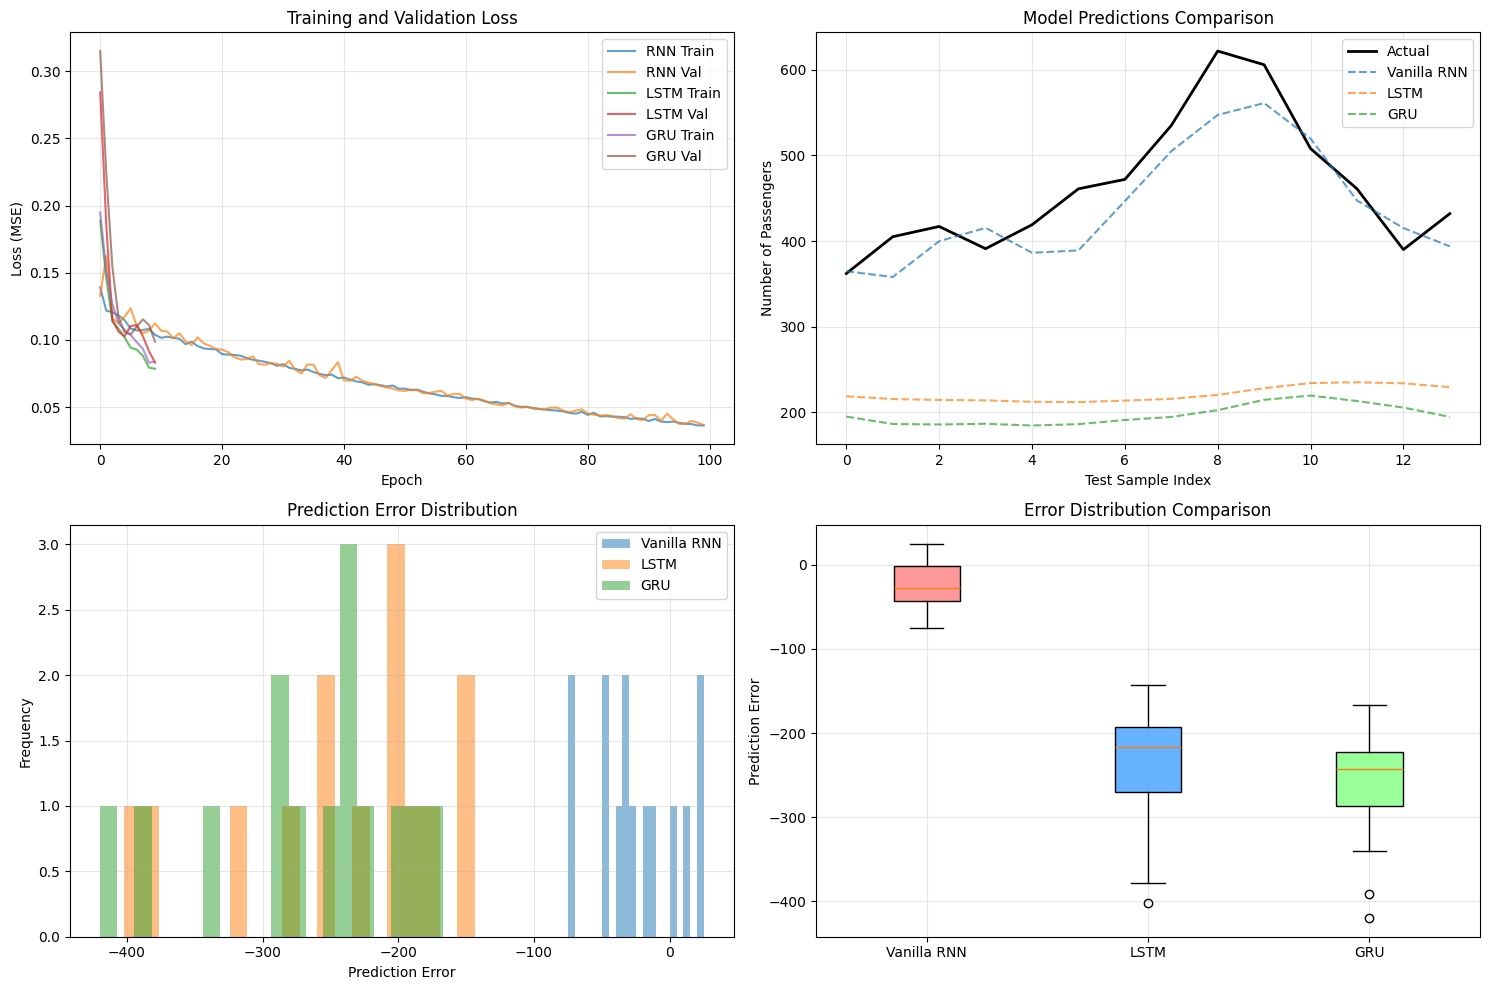

In [12]:
# Comparing models

def evaluate_model(model, X_test, y_test, scaler, model_name):

    predictions = model.predict(X_test, verbose=0)

    # Inverse transform to original scale
    predictions_original = scaler.inverse_transform(predictions)
    y_test_original = scaler.inverse_transform(y_test)

    # Calculate metrics
    mse = np.mean((predictions_original - y_test_original) ** 2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test_original - predictions_original) / y_test_original)) * 100

    print(f"\n{model_name} Results:")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

    return predictions_original, y_test_original, rmse, mape


# Evaluate all three models
print("\nEvaluating on test set...")
pred_vrnn, actual, rmse_vrnn, mape_vrnn = evaluate_model(vanilla_rnn, X_test, y_test, scaler, "Vanilla RNN")
pred_lstm, actual, rmse_lstm, mape_lstm = evaluate_model(lstm, X_test, y_test, scaler, "LSTM")
pred_gru, actual, rmse_gru, mape_gru = evaluate_model(gru, X_test, y_test, scaler, "GRU")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training loss curves
ax = axes[0, 0]
ax.plot(history_vrnn.history['loss'], label='RNN Train', alpha=0.7)
ax.plot(history_vrnn.history['val_loss'], label='RNN Val', alpha=0.7)
ax.plot(history_lstm.history['loss'], label='LSTM Train', alpha=0.7)
ax.plot(history_lstm.history['val_loss'], label='LSTM Val', alpha=0.7)
ax.plot(history_gru.history['loss'], label='GRU Train', alpha=0.7)
ax.plot(history_gru.history['val_loss'], label='GRU Val', alpha=0.7)
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Predictions vs Actual
ax = axes[0, 1]
ax.plot(actual, label='Actual', linewidth=2, color='black')
ax.plot(pred_vrnn, label='Vanilla RNN', linestyle='--', alpha=0.7)
ax.plot(pred_lstm, label='LSTM', linestyle='--', alpha=0.7)
ax.plot(pred_gru, label='GRU', linestyle='--', alpha=0.7)
ax.set_title('Model Predictions Comparison')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Number of Passengers')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Error distribution
ax = axes[1, 0]
errors_vrnn = pred_vrnn.flatten() - actual.flatten()
errors_lstm = pred_lstm.flatten() - actual.flatten()
errors_gru = pred_gru.flatten() - actual.flatten()
ax.hist(errors_vrnn, bins=20, alpha=0.5, label='Vanilla RNN')
ax.hist(errors_lstm, bins=20, alpha=0.5, label='LSTM')
ax.hist(errors_gru, bins=20, alpha=0.5, label='GRU')
ax.set_title('Prediction Error Distribution')
ax.set_xlabel('Prediction Error')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Box plot comparison
ax = axes[1, 1]
data_to_plot = [errors_vrnn, errors_lstm, errors_gru]
bp = ax.boxplot(data_to_plot, labels=['Vanilla RNN', 'LSTM', 'GRU'], patch_artist=True)
bp['boxes'][0].set_facecolor('#FF9999')
bp['boxes'][1].set_facecolor('#66B2FF')
bp['boxes'][2].set_facecolor('#99FF99')
ax.set_title('Error Distribution Comparison')
ax.set_ylabel('Prediction Error')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


>As we can see Vanilla RNN model outperforms the 2 other models.

## Sequence Components Analysis

1. Sequence Length


Testing different sequence lengths (how many past months to use for prediction):
------------------------------------------------------------

 Testing sequence length: 4 months


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 160.60
  Mean Absolute Percentage Error (MAPE): 32.36%



LSTM Results:
  Root Mean Squared Error (RMSE): 98.32
  Mean Absolute Percentage Error (MAPE): 16.42%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...


Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 82.16
  Mean Absolute Percentage Error (MAPE): 15.15%

LSTM Results:
  Root Mean Squared Error (RMSE): 79.97
  Mean Absolute Percentage Error (MAPE): 12.27%

GRU Results:
  Root Mean Squared Error (RMSE): 90.67
  Mean Absolute Percentage Error (MAPE): 13.39%

 Testing sequence length: 30 months


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 90.22
  Mean Absolute Percentage Error (MAPE): 16.69%

LSTM Results:
  Root Mean Squared Error (RMSE): 81.66
  Mean Absolute Percentage Error (MAPE): 12.24%

GRU Results:
  Root Mean Squared Error (RMSE): 91.22
  Mean Absolute Percentage Error (MAPE): 13.46%

 Testing sequence length: 36 months


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 93.50
  Mean Absolute Percentage Error (MAPE): 17.30%

LSTM Results:
  Root Mean Squared Error (RMSE): 100.14
  Mean Absolute Percentage Error (MAPE): 13.78%

GRU Results:
  Root Mean Squared Error (RMSE): 93.12
  Mean Absolute Percentage Error (MAPE): 13.85%

SUMMARY OF BEST RESULTS:
Vanilla RNN - Best sequence length: 12 months
  RMSE: 38.66, MAPE: 6.94%

LSTM - Best sequence length: 12 months
  RMSE: 74.86, MAPE: 13.13%

GRU - Best sequence length: 4 months
  RMSE: 78.58, MAPE: 14.03%


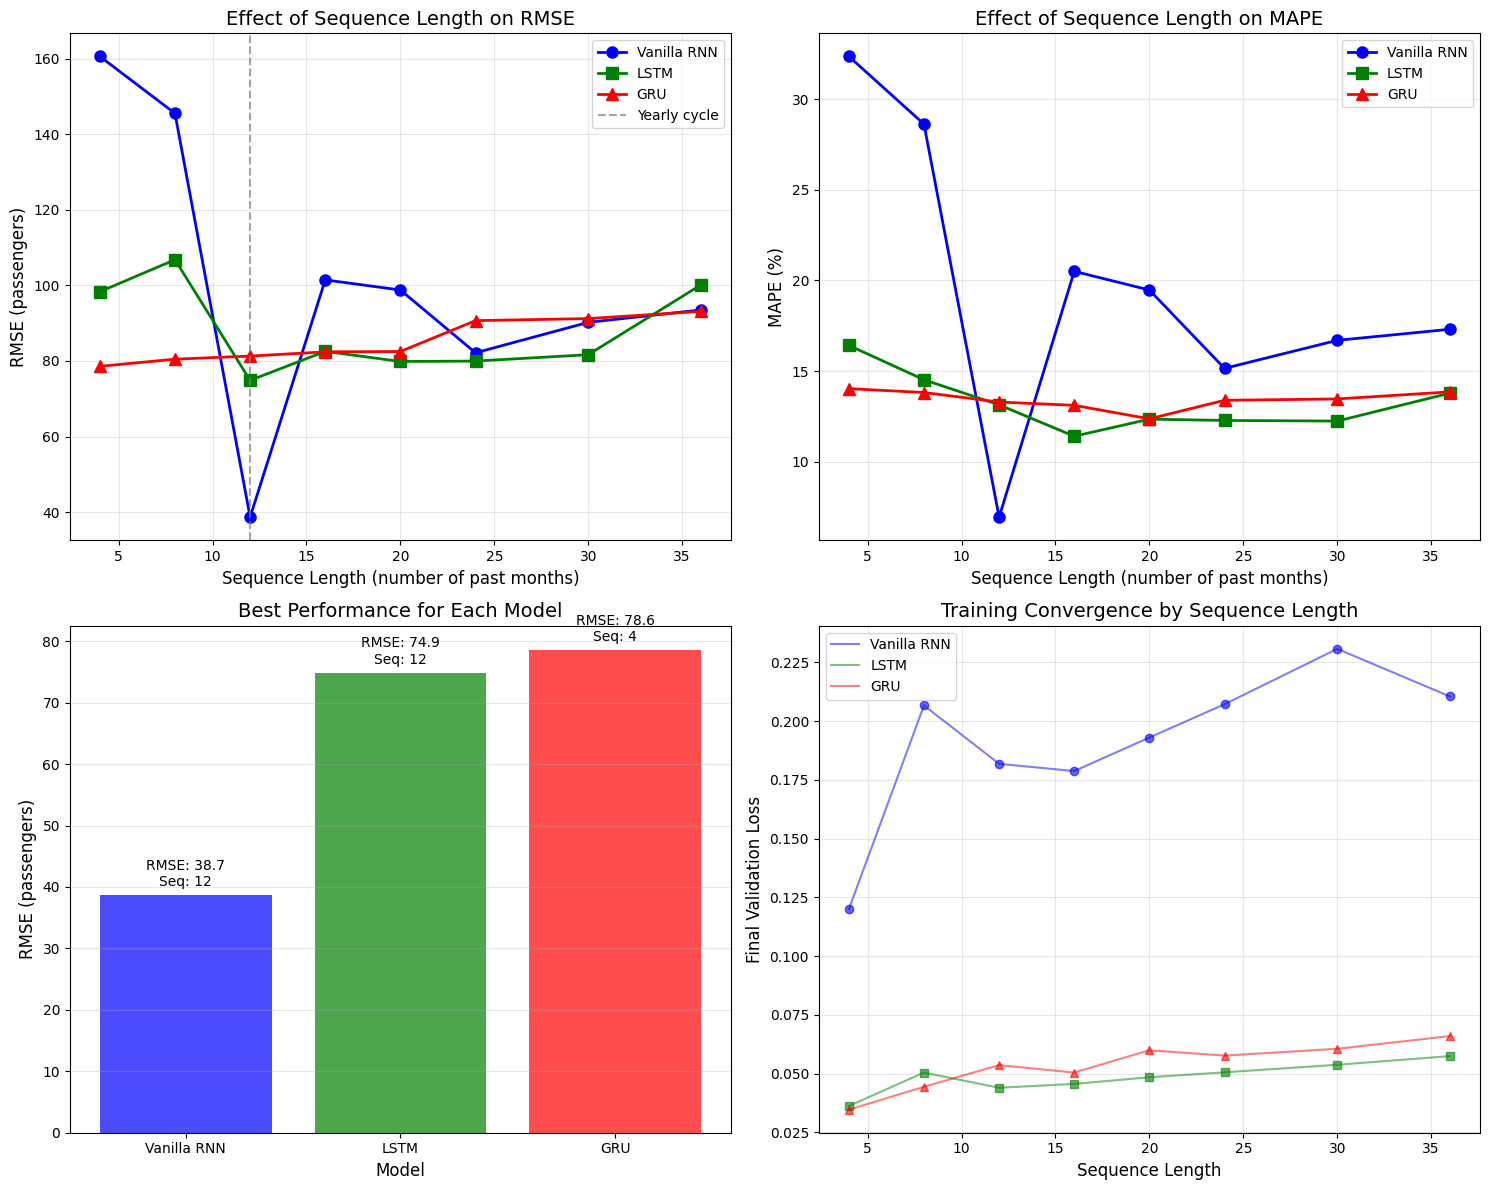

In [13]:
# Analyze the effect of sequence length

# Fixed parameters
SEQUENCE_LENGTH = 12
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 32
EPOCHS = 50
DROPOUT_BETWEEN_LAYERS = 0.2  # Fixed dropout
RECURRENT_DROPOUT = 0.0
BIDIRECTIONAL = False

sequence_lengths = [4, 8, 12, 16, 20, 24, 30, 36]
results_vrnn = {}
results_lstm = {}
results_gru = {}

print("\nTesting different sequence lengths (how many past months to use for prediction):")
print("-"*60)

for seq_len in sequence_lengths:
    print(f"\n Testing sequence length: {seq_len} months")

    # Create sequences
    X, y = create_sequences(data_scaled, seq_len)


    # Split data
    X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

    # Create models
    vrnn = create_vanilla_rnn(seq_length=SEQUENCE_LENGTH,
                              hidden_size=HIDDEN_SIZE,
                              num_layers=NUM_LAYERS,
                              dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                              recurrent_dropout=RECURRENT_DROPOUT,
                              bidirectional=BIDIRECTIONAL)

    lstm = create_lstm(seq_length=SEQUENCE_LENGTH,
                       hidden_size=HIDDEN_SIZE,
                       num_layers=NUM_LAYERS,
                       dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                       recurrent_dropout=RECURRENT_DROPOUT,
                       bidirectional=BIDIRECTIONAL)

    gru = create_gru(seq_length=SEQUENCE_LENGTH,
                     hidden_size=HIDDEN_SIZE,
                     num_layers=NUM_LAYERS,
                     dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                     recurrent_dropout=RECURRENT_DROPOUT,
                     bidirectional=BIDIRECTIONAL)

    # Train
    history_vrnn = vrnn.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    history_lstm = lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    history_gru = gru.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)

    # Evaluate
    pred_vrnn, actual, rmse_vrnn, mape_vrnn = evaluate_model(vanilla_rnn, X_test, y_test, scaler, "Vanilla RNN")
    pred_lstm, actual, rmse_lstm, mape_lstm = evaluate_model(lstm, X_test, y_test, scaler, "LSTM")
    pred_gru, actual, rmse_gru, mape_gru = evaluate_model(gru, X_test, y_test, scaler, "GRU")


    results_vrnn[seq_len] = {'RMSE': rmse_vrnn, 'MAPE': mape_vrnn, 'final_loss': history_vrnn.history['val_loss'][-1]}
    results_lstm[seq_len] = {'RMSE': rmse_lstm, 'MAPE': mape_lstm, 'final_loss': history_lstm.history['val_loss'][-1]}
    results_gru[seq_len] = {'RMSE': rmse_gru, 'MAPE': mape_gru, 'final_loss': history_gru.history['val_loss'][-1]}



# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: RMSE vs Sequence Length
ax = axes[0, 0]
ax.plot(sequence_lengths, [results_vrnn[sl]['RMSE'] for sl in sequence_lengths],
        'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax.plot(sequence_lengths, [results_lstm[sl]['RMSE'] for sl in sequence_lengths],
        's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax.plot(sequence_lengths, [results_gru[sl]['RMSE'] for sl in sequence_lengths],
        '^-', linewidth=2, markersize=8, label='GRU', color='red')

ax.set_xlabel('Sequence Length (number of past months)', fontsize=12)
ax.set_ylabel('RMSE (passengers)', fontsize=12)
ax.set_title('Effect of Sequence Length on RMSE', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.axvline(x=12, color='gray', linestyle='--', alpha=0.7, label='Yearly cycle')
ax.legend()

# Plot 2: MAPE vs Sequence Length
ax = axes[0, 1]
ax.plot(sequence_lengths, [results_vrnn[sl]['MAPE'] for sl in sequence_lengths],
        'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax.plot(sequence_lengths, [results_lstm[sl]['MAPE'] for sl in sequence_lengths],
        's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax.plot(sequence_lengths, [results_gru[sl]['MAPE'] for sl in sequence_lengths],
        '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax.set_xlabel('Sequence Length (number of past months)', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('Effect of Sequence Length on MAPE', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Bar chart comparison for best sequence length
ax = axes[1, 0]
best_len_vrnn = min(results_vrnn.items(), key=lambda x: x[1]['RMSE'])[0]
best_len_lstm = min(results_lstm.items(), key=lambda x: x[1]['RMSE'])[0]
best_len_gru = min(results_gru.items(), key=lambda x: x[1]['RMSE'])[0]

models = ['Vanilla RNN', 'LSTM', 'GRU']
best_lengths = [best_len_vrnn, best_len_lstm, best_len_gru]
best_rmses = [results_vrnn[best_len_vrnn]['RMSE'],
              results_lstm[best_len_lstm]['RMSE'],
              results_gru[best_len_gru]['RMSE']]

colors = ['blue', 'green', 'red']
bars = ax.bar(models, best_rmses, color=colors, alpha=0.7)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('RMSE (passengers)', fontsize=12)
ax.set_title(f'Best Performance for Each Model', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value, length in zip(bars, best_rmses, best_lengths):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'RMSE: {value:.1f}\nSeq: {length}', ha='center', va='bottom')

# Plot 4: Final validation loss comparison
ax = axes[1, 1]
for seq_len in sequence_lengths:
    ax.plot(seq_len, results_vrnn[seq_len]['final_loss'], 'bo', markersize=6, alpha=0.6)
    ax.plot(seq_len, results_lstm[seq_len]['final_loss'], 'gs', markersize=6, alpha=0.6)
    ax.plot(seq_len, results_gru[seq_len]['final_loss'], 'r^', markersize=6, alpha=0.6)

# Add trend lines
vrnn_losses = [results_vrnn[sl]['final_loss'] for sl in sequence_lengths]
lstm_losses = [results_lstm[sl]['final_loss'] for sl in sequence_lengths]
gru_losses = [results_gru[sl]['final_loss'] for sl in sequence_lengths]

ax.plot(sequence_lengths, vrnn_losses, 'b-', alpha=0.5, label='Vanilla RNN')
ax.plot(sequence_lengths, lstm_losses, 'g-', alpha=0.5, label='LSTM')
ax.plot(sequence_lengths, gru_losses, 'r-', alpha=0.5, label='GRU')

ax.set_xlabel('Sequence Length', fontsize=12)
ax.set_ylabel('Final Validation Loss', fontsize=12)
ax.set_title('Training Convergence by Sequence Length', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Summary
print("\n" + "="*60)
print("SUMMARY OF BEST RESULTS:")
print("="*60)
print(f"Vanilla RNN - Best sequence length: {best_len_vrnn} months")
print(f"  RMSE: {results_vrnn[best_len_vrnn]['RMSE']:.2f}, MAPE: {results_vrnn[best_len_vrnn]['MAPE']:.2f}%")
print(f"\nLSTM - Best sequence length: {best_len_lstm} months")
print(f"  RMSE: {results_lstm[best_len_lstm]['RMSE']:.2f}, MAPE: {results_lstm[best_len_lstm]['MAPE']:.2f}%")
print(f"\nGRU - Best sequence length: {best_len_gru} months")
print(f"  RMSE: {results_gru[best_len_gru]['RMSE']:.2f}, MAPE: {results_gru[best_len_gru]['MAPE']:.2f}%")

plt.tight_layout()
plt.show()



>In this part we trained the 3 models with different number of sequence lengths, based on the RMSE, the vanilla and LSTM models perform best when the sequence length is 12 months, but the GRU model's best performance is when the sequence length is 4.

2. Hidden Size


Testing different hidden sizes:
------------------------------------------------------------

 Testing hidden size: 4 units


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 38.66
  Mean Absolute Percentage Error (MAPE): 6.94%

LSTM Results:
  Root Mean Squared Error (RMSE): 108.29
  Mean Absolute Percentage Error (MAPE): 15.48%

GRU Results:
  Root Mean Squared Error (RMSE): 109.89
  Mean Absolute Percentage Error (MAPE): 17.27%

 Testing hidden size: 8 units


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 38.66
  Mean Absolute Percentage Error (MAPE): 6.94%

LSTM Results:
  Root Mean Squared Error (RMSE): 92.31
  Mean Absolute Percentage Error (MAPE): 12.21%

GRU Results:
  Root Mean Squared Error (RMSE): 96.12
  Mean Absolute Percentage Error (MAPE): 14.13%

 Testing hidden size: 16 units


...


Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 38.66
  Mean Absolute Percentage Error (MAPE): 6.94%

LSTM Results:
  Root Mean Squared Error (RMSE): 75.85
  Mean Absolute Percentage Error (MAPE): 13.26%

GRU Results:
  Root Mean Squared Error (RMSE): 86.48
  Mean Absolute Percentage Error (MAPE): 13.21%

 Testing hidden size: 128 units


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 38.66
  Mean Absolute Percentage Error (MAPE): 6.94%

LSTM Results:
  Root Mean Squared Error (RMSE): 72.27
  Mean Absolute Percentage Error (MAPE): 12.02%

GRU Results:
  Root Mean Squared Error (RMSE): 80.37
  Mean Absolute Percentage Error (MAPE): 14.06%

 Testing hidden size: 256 units


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 38.66
  Mean Absolute Percentage Error (MAPE): 6.94%

LSTM Results:
  Root Mean Squared Error (RMSE): 75.47
  Mean Absolute Percentage Error (MAPE): 13.93%

GRU Results:
  Root Mean Squared Error (RMSE): 81.24
  Mean Absolute Percentage Error (MAPE): 13.43%


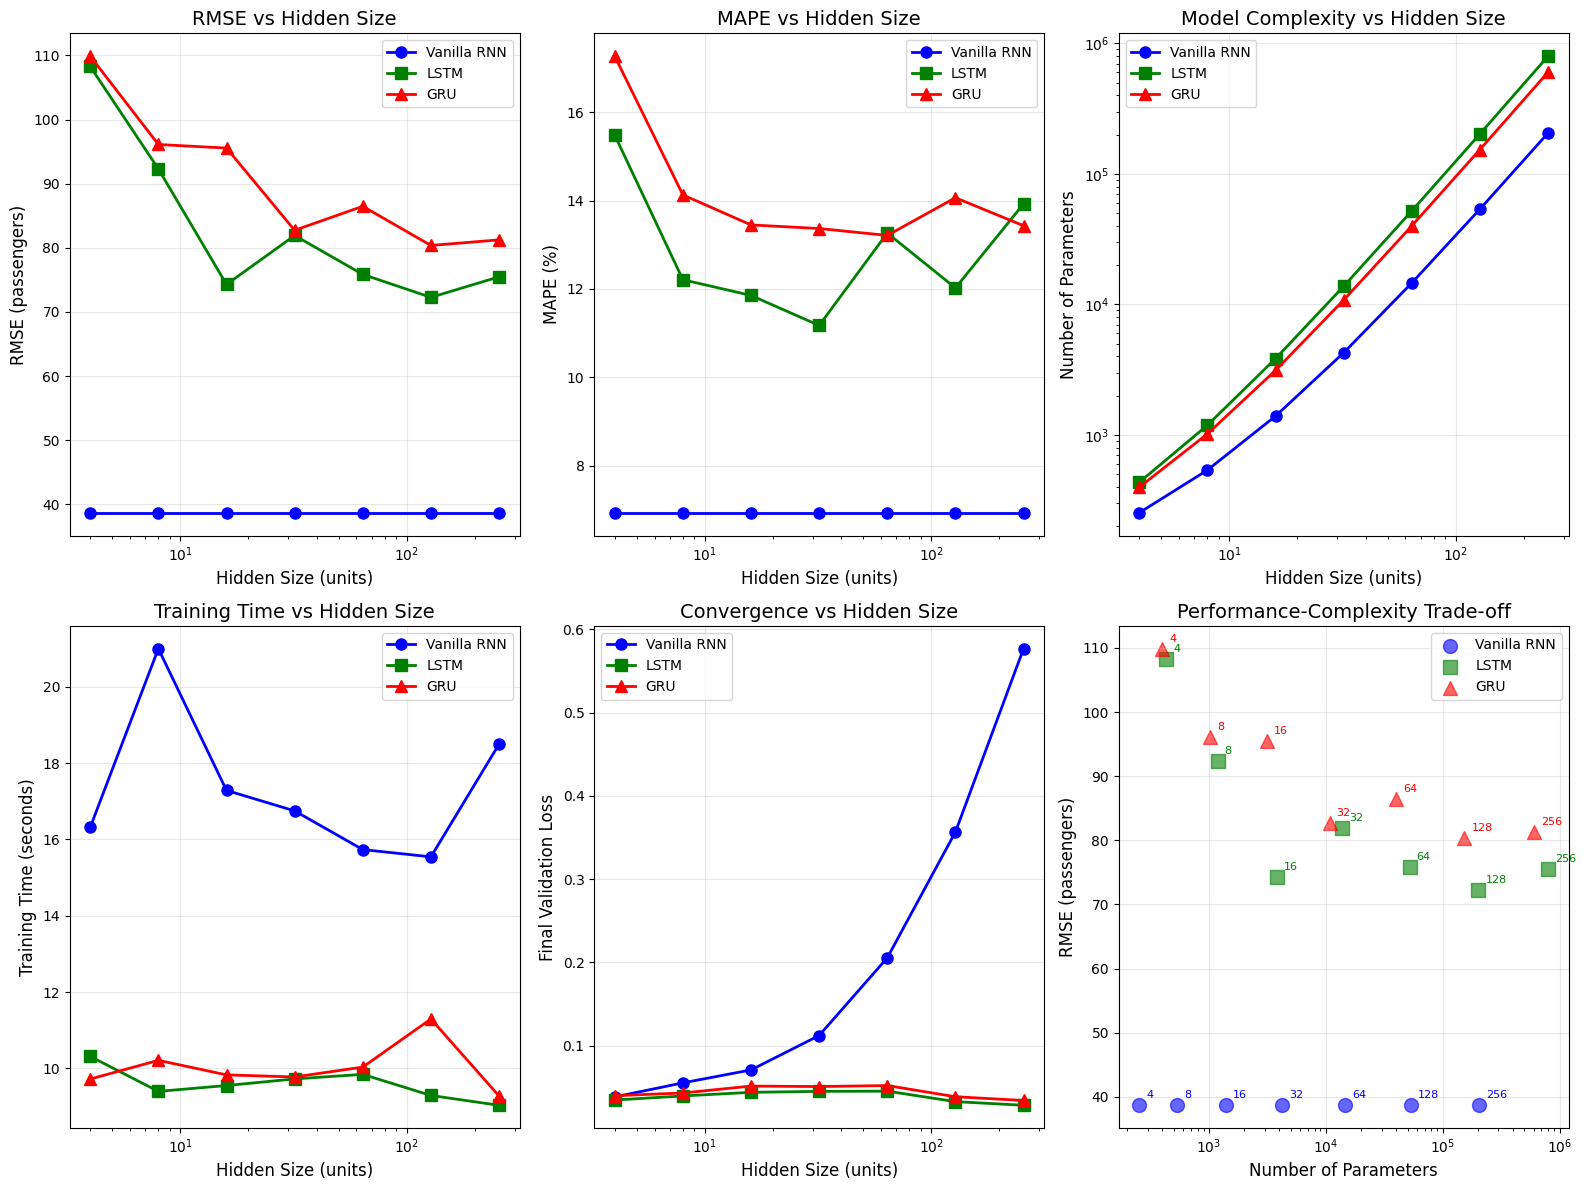


SUMMARY OF HIDDEN SIZE ANALYSIS:

 VANILLA RNN:
  Best hidden size: 4 units
  RMSE: 38.66
  MAPE: 6.94%
  Parameters: 253
  Training time: 16.32 seconds

 LSTM:
  Best hidden size: 128 units
  RMSE: 72.27
  MAPE: 12.02%
  Parameters: 202,305
  Training time: 9.29 seconds

 GRU:
  Best hidden size: 128 units
  RMSE: 80.37
  MAPE: 14.06%
  Parameters: 153,537
  Training time: 11.29 seconds


In [16]:
# Analyse the effect of hidden size

# Fixed parameters
SEQUENCE_LENGTH = 12
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 32
EPOCHS = 50
DROPOUT_BETWEEN_LAYERS = 0.2  # Fixed dropout
RECURRENT_DROPOUT = 0.0
BIDIRECTIONAL = False

hidden_sizes = [4, 8, 16, 32, 64, 128, 256]
results = {}

print("\nTesting different hidden sizes:")
print("-"*60)

for hidden_size in hidden_sizes:
    print(f"\n Testing hidden size: {hidden_size} units")

    # Create sequences
    X, y = create_sequences(data_scaled, seq_length=SEQUENCE_LENGTH)


    # Split data
    X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

    # Create models
    vrnn = create_vanilla_rnn(seq_length=SEQUENCE_LENGTH,
                              hidden_size=hidden_size,
                              num_layers=NUM_LAYERS,
                              dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                              recurrent_dropout=RECURRENT_DROPOUT,
                              bidirectional=BIDIRECTIONAL)

    lstm = create_lstm(seq_length=SEQUENCE_LENGTH,
                       hidden_size=hidden_size,
                       num_layers=NUM_LAYERS,
                       dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                       recurrent_dropout=RECURRENT_DROPOUT,
                       bidirectional=BIDIRECTIONAL)

    gru = create_gru(seq_length=SEQUENCE_LENGTH,
                     hidden_size=hidden_size,
                     num_layers=NUM_LAYERS,
                     dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                     recurrent_dropout=RECURRENT_DROPOUT,
                     bidirectional=BIDIRECTIONAL)


    # Count parameters
    param_count_vrnn = vrnn.count_params()
    param_count_lstm = lstm.count_params()
    param_count_gru = gru.count_params()

    # Train Vanilla RNN
    start_time = time.time()
    history_vrnn = vrnn.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    training_time_vrnn = time.time() - start_time

    # Train LSTM
    start_time = time.time()
    history_lstm = lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    training_time_lstm = time.time() - start_time

    # Train GRU
    start_time = time.time()
    history_gru = gru.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    training_time_gru = time.time() - start_time


    # Evaluate
    pred_vrnn, actual, rmse_vrnn, mape_vrnn = evaluate_model(vanilla_rnn, X_test, y_test, scaler, "Vanilla RNN")
    pred_lstm, actual, rmse_lstm, mape_lstm = evaluate_model(lstm, X_test, y_test, scaler, "LSTM")
    pred_gru, actual, rmse_gru, mape_gru = evaluate_model(gru, X_test, y_test, scaler, "GRU")


    results_vrnn[hidden_size] = {'RMSE': rmse_vrnn, 'MAPE': mape_vrnn, 'Parameters': param_count_vrnn, 'Training_Time': training_time_vrnn, 'final_loss': history_vrnn.history['val_loss'][-1]}
    results_lstm[hidden_size] = {'RMSE': rmse_lstm, 'MAPE': mape_lstm, 'Parameters': param_count_lstm, 'Training_Time': training_time_lstm, 'final_loss': history_lstm.history['val_loss'][-1]}
    results_gru[hidden_size] = {'RMSE': rmse_gru, 'MAPE': mape_gru, 'Parameters': param_count_gru, 'Training_Time': training_time_gru, 'final_loss': history_gru.history['val_loss'][-1]}


# Visualization
fig = plt.figure(figsize=(16, 12))

# Plot 1: RMSE vs Hidden Size (Log scale for x-axis)
ax1 = plt.subplot(2, 3, 1)
ax1.plot(hidden_sizes, [results_vrnn[hs]['RMSE'] for hs in hidden_sizes],
         'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax1.plot(hidden_sizes, [results_lstm[hs]['RMSE'] for hs in hidden_sizes],
         's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax1.plot(hidden_sizes, [results_gru[hs]['RMSE'] for hs in hidden_sizes],
         '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax1.set_xlabel('Hidden Size (units)', fontsize=12)
ax1.set_ylabel('RMSE (passengers)', fontsize=12)
ax1.set_title('RMSE vs Hidden Size', fontsize=14)
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: MAPE vs Hidden Size
ax2 = plt.subplot(2, 3, 2)
ax2.plot(hidden_sizes, [results_vrnn[hs]['MAPE'] for hs in hidden_sizes],
         'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax2.plot(hidden_sizes, [results_lstm[hs]['MAPE'] for hs in hidden_sizes],
         's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax2.plot(hidden_sizes, [results_gru[hs]['MAPE'] for hs in hidden_sizes],
         '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax2.set_xlabel('Hidden Size (units)', fontsize=12)
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_title('MAPE vs Hidden Size', fontsize=14)
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Parameter count vs Hidden Size
ax3 = plt.subplot(2, 3, 3)
ax3.plot(hidden_sizes, [results_vrnn[hs]['Parameters'] for hs in hidden_sizes],
         'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax3.plot(hidden_sizes, [results_lstm[hs]['Parameters'] for hs in hidden_sizes],
         's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax3.plot(hidden_sizes, [results_gru[hs]['Parameters'] for hs in hidden_sizes],
         '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax3.set_xlabel('Hidden Size (units)', fontsize=12)
ax3.set_ylabel('Number of Parameters', fontsize=12)
ax3.set_title('Model Complexity vs Hidden Size', fontsize=14)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Training Time vs Hidden Size
ax4 = plt.subplot(2, 3, 4)
ax4.plot(hidden_sizes, [results_vrnn[hs]['Training_Time'] for hs in hidden_sizes],
         'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax4.plot(hidden_sizes, [results_lstm[hs]['Training_Time'] for hs in hidden_sizes],
         's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax4.plot(hidden_sizes, [results_gru[hs]['Training_Time'] for hs in hidden_sizes],
         '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax4.set_xlabel('Hidden Size (units)', fontsize=12)
ax4.set_ylabel('Training Time (seconds)', fontsize=12)
ax4.set_title('Training Time vs Hidden Size', fontsize=14)
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)
ax4.legend()

# Plot 5: Final Validation Loss vs Hidden Size
ax5 = plt.subplot(2, 3, 5)
ax5.plot(hidden_sizes, [results_vrnn[hs]['final_loss'] for hs in hidden_sizes],
         'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax5.plot(hidden_sizes, [results_lstm[hs]['final_loss'] for hs in hidden_sizes],
         's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax5.plot(hidden_sizes, [results_gru[hs]['final_loss'] for hs in hidden_sizes],
         '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax5.set_xlabel('Hidden Size (units)', fontsize=12)
ax5.set_ylabel('Final Validation Loss', fontsize=12)
ax5.set_title('Convergence vs Hidden Size', fontsize=14)
ax5.set_xscale('log')
ax5.grid(True, alpha=0.3)
ax5.legend()

# Plot 6: Performance vs Complexity trade-off (RMSE vs Parameters)
ax6 = plt.subplot(2, 3, 6)
for hs in hidden_sizes:
    ax6.scatter(results_vrnn[hs]['Parameters'], results_vrnn[hs]['RMSE'],
                s=100, c='blue', alpha=0.6, marker='o')
    ax6.scatter(results_lstm[hs]['Parameters'], results_lstm[hs]['RMSE'],
                s=100, c='green', alpha=0.6, marker='s')
    ax6.scatter(results_gru[hs]['Parameters'], results_gru[hs]['RMSE'],
                s=100, c='red', alpha=0.6, marker='^')

    # Annotate with hidden size
    ax6.annotate(str(hs),
                xy=(results_vrnn[hs]['Parameters'], results_vrnn[hs]['RMSE']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='blue')
    ax6.annotate(str(hs),
                xy=(results_lstm[hs]['Parameters'], results_lstm[hs]['RMSE']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='green')
    ax6.annotate(str(hs),
                xy=(results_gru[hs]['Parameters'], results_gru[hs]['RMSE']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='red')

ax6.set_xlabel('Number of Parameters', fontsize=12)
ax6.set_ylabel('RMSE (passengers)', fontsize=12)
ax6.set_title('Performance-Complexity Trade-off', fontsize=14)
ax6.set_xscale('log')
ax6.grid(True, alpha=0.3)
ax6.legend(['Vanilla RNN', 'LSTM', 'GRU'])

plt.tight_layout()
plt.show()

# Find optimal hidden sizes
best_hidden_vrnn = min(results_vrnn.items(), key=lambda x: x[1]['RMSE'])[0]
best_hidden_lstm = min(results_lstm.items(), key=lambda x: x[1]['RMSE'])[0]
best_hidden_gru = min(results_gru.items(), key=lambda x: x[1]['RMSE'])[0]

# Summary
print("\n" + "="*80)
print("SUMMARY OF HIDDEN SIZE ANALYSIS:")
print("="*80)

print("\n VANILLA RNN:")
print(f"  Best hidden size: {best_hidden_vrnn} units")
print(f"  RMSE: {results_vrnn[best_hidden_vrnn]['RMSE']:.2f}")
print(f"  MAPE: {results_vrnn[best_hidden_vrnn]['MAPE']:.2f}%")
print(f"  Parameters: {results_vrnn[best_hidden_vrnn]['Parameters']:,}")
print(f"  Training time: {results_vrnn[best_hidden_vrnn]['Training_Time']:.2f} seconds")

print("\n LSTM:")
print(f"  Best hidden size: {best_hidden_lstm} units")
print(f"  RMSE: {results_lstm[best_hidden_lstm]['RMSE']:.2f}")
print(f"  MAPE: {results_lstm[best_hidden_lstm]['MAPE']:.2f}%")
print(f"  Parameters: {results_lstm[best_hidden_lstm]['Parameters']:,}")
print(f"  Training time: {results_lstm[best_hidden_lstm]['Training_Time']:.2f} seconds")

print("\n GRU:")
print(f"  Best hidden size: {best_hidden_gru} units")
print(f"  RMSE: {results_gru[best_hidden_gru]['RMSE']:.2f}")
print(f"  MAPE: {results_gru[best_hidden_gru]['MAPE']:.2f}%")
print(f"  Parameters: {results_gru[best_hidden_gru]['Parameters']:,}")
print(f"  Training time: {results_gru[best_hidden_gru]['Training_Time']:.2f} seconds")



>In this part we changed the number of hidden size and based on the summary for the Vanilla RNN model, the best hidden size is 4 but for the 2 other models we should increase the hidden size to get the best performance.

3. Number of Layers


ANALYZING EFFECT OF NUMBER OF RECURRENT LAYERS

Testing 1 recurrent layer(s):
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 65.19
  Mean Absolute Percentage Error (MAPE): 11.74%

LSTM Results:
  Root Mean Squared Error (RMSE): 74.89
  Mean Absolute Percentage Error (MAPE): 12.81%

GRU Results:
  Root Mean Squared Error (RMSE): 71.84
  Mean Absolute Percentage Error (MAPE): 11.61%

Testing 2 recurrent layer(s):
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 61.54
  Mean Absolute Percentage Error (MAPE): 12.84%

LSTM Results:
  Root Mean Squared Error (RMSE): 72.66
  Mean Absolute Percentage Error (MAPE): 12.19%

GRU Results:
  Root Mean Squared Error (RMSE): 81.47
  Mean Absolute Percentage Error (MAPE): 14.63%

Testing 3 recurrent layer(s):
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 115.58
  Mean Absolute Percentage Error (MAPE): 22.75%

LSTM Results:
  Root Mean Squared Error (RMSE): 67.58
  Mean Absolute Percentage Error (MAPE): 11.79%

GRU Results:
  Root Mean Squared Error (RMSE): 86.38
  Mean Absolute Percentage Error (MAPE): 14.86%


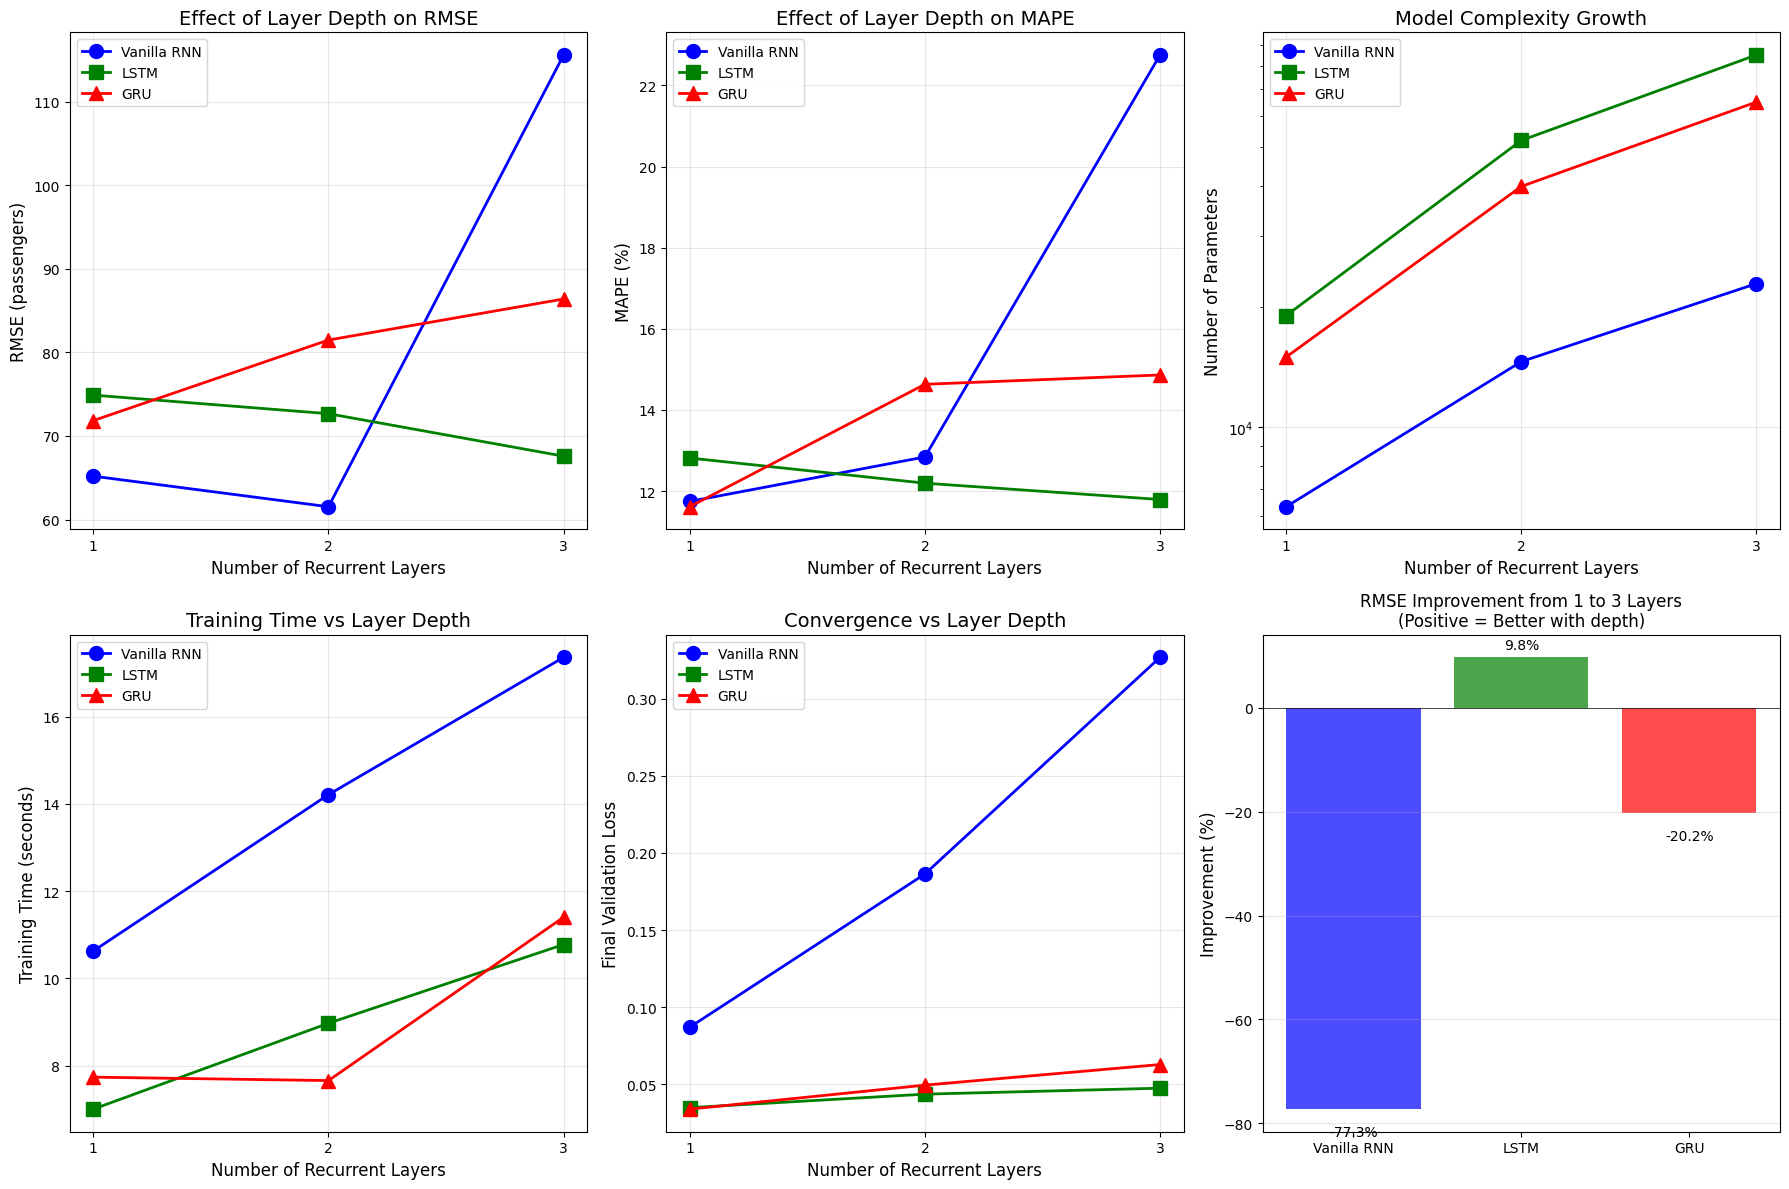


SUMMARY: EFFECT OF RECURRENT LAYERS

 1 LAYER(S):
  Model           RMSE       MAPE       Params       Time(s)   
  ------------------------------------------------------------
  Vanilla RNN     65.19      11.74      6,337        10.63     
  LSTM            74.89      12.81      19,009       7.01      
  GRU             71.84      11.61      14,977       7.74      

 2 LAYER(S):
  Model           RMSE       MAPE       Params       Time(s)   
  ------------------------------------------------------------
  Vanilla RNN     61.54      12.84      14,593       14.21     
  LSTM            72.66      12.19      52,033       8.97      
  GRU             81.47      14.63      39,937       7.66      

 3 LAYER(S):
  Model           RMSE       MAPE       Params       Time(s)   
  ------------------------------------------------------------
  Vanilla RNN     115.58     22.75      22,849       17.36     
  LSTM            67.58      11.79      85,057       10.78     
  GRU             86.38     

In [18]:
# Analyse the effect of number of layers

# Fixed parameters
SEQUENCE_LENGTH = 12
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 32
EPOCHS = 50
DROPOUT_BETWEEN_LAYERS = 0.2  # Fixed dropout
RECURRENT_DROPOUT = 0.0
BIDIRECTIONAL = False

num_layers_options = [1, 2, 3]

# Results dictionaries
results_vrnn_layers = {}
results_lstm_layers = {}
results_gru_layers = {}

print("\n" + "="*80)
print("ANALYZING EFFECT OF NUMBER OF RECURRENT LAYERS")
print("="*80)

# Create sequences once (same for all)
X, y = create_sequences(data_scaled, seq_length=SEQUENCE_LENGTH)

# Split data
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

for num_layers in num_layers_options:
    print(f"\nTesting {num_layers} recurrent layer(s):")
    print("-"*40)

    # Create models
    vrnn = create_vanilla_rnn(seq_length=SEQUENCE_LENGTH,
                              hidden_size=HIDDEN_SIZE,
                              num_layers=num_layers,
                              dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                              recurrent_dropout=RECURRENT_DROPOUT,
                              bidirectional=BIDIRECTIONAL)

    lstm = create_lstm(seq_length=SEQUENCE_LENGTH,
                       hidden_size=HIDDEN_SIZE,
                       num_layers=num_layers,
                       dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                       recurrent_dropout=RECURRENT_DROPOUT,
                       bidirectional=BIDIRECTIONAL)

    gru = create_gru(seq_length=SEQUENCE_LENGTH,
                     hidden_size=HIDDEN_SIZE,
                     num_layers=num_layers,
                     dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                     recurrent_dropout=RECURRENT_DROPOUT,
                     bidirectional=BIDIRECTIONAL)

    # Count parameters
    params_vrnn = vrnn.count_params()
    params_lstm = lstm.count_params()
    params_gru = gru.count_params()


    # Train Vanilla RNN
    start_time = time.time()
    history_vrnn = vrnn.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    time_vrnn = time.time() - start_time

    # Train LSTM
    start_time = time.time()
    history_lstm = lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    time_lstm = time.time() - start_time

    # Train GRU
    start_time = time.time()
    history_gru = gru.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    time_gru = time.time() - start_time

    # Evaluate
    pred_vrnn, actual, rmse_vrnn, mape_vrnn = evaluate_model(vrnn, X_test, y_test, scaler, "Vanilla RNN")
    pred_lstm, actual, rmse_lstm, mape_lstm = evaluate_model(lstm, X_test, y_test, scaler, "LSTM")
    pred_gru, actual, rmse_gru, mape_gru = evaluate_model(gru, X_test, y_test, scaler, "GRU")

    # Store results
    results_vrnn_layers[num_layers] = {
        'RMSE': rmse_vrnn,
        'MAPE': mape_vrnn,
        'Parameters': params_vrnn,
        'Training_Time': time_vrnn,
        'final_loss': history_vrnn.history['val_loss'][-1]
    }
    results_lstm_layers[num_layers] = {
        'RMSE': rmse_lstm,
        'MAPE': mape_lstm,
        'Parameters': params_lstm,
        'Training_Time': time_lstm,
        'final_loss': history_lstm.history['val_loss'][-1]
    }
    results_gru_layers[num_layers] = {
        'RMSE': rmse_gru,
        'MAPE': mape_gru,
        'Parameters': params_gru,
        'Training_Time': time_gru,
        'final_loss': history_gru.history['val_loss'][-1]
    }



# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: RMSE vs Number of Layers
ax = axes[0, 0]
ax.plot(num_layers_options, [results_vrnn_layers[n]['RMSE'] for n in num_layers_options],
        'o-', linewidth=2, markersize=10, label='Vanilla RNN', color='blue')
ax.plot(num_layers_options, [results_lstm_layers[n]['RMSE'] for n in num_layers_options],
        's-', linewidth=2, markersize=10, label='LSTM', color='green')
ax.plot(num_layers_options, [results_gru_layers[n]['RMSE'] for n in num_layers_options],
        '^-', linewidth=2, markersize=10, label='GRU', color='red')
ax.set_xlabel('Number of Recurrent Layers', fontsize=12)
ax.set_ylabel('RMSE (passengers)', fontsize=12)
ax.set_title('Effect of Layer Depth on RMSE', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(num_layers_options)

# Plot 2: MAPE vs Number of Layers
ax = axes[0, 1]
ax.plot(num_layers_options, [results_vrnn_layers[n]['MAPE'] for n in num_layers_options],
        'o-', linewidth=2, markersize=10, label='Vanilla RNN', color='blue')
ax.plot(num_layers_options, [results_lstm_layers[n]['MAPE'] for n in num_layers_options],
        's-', linewidth=2, markersize=10, label='LSTM', color='green')
ax.plot(num_layers_options, [results_gru_layers[n]['MAPE'] for n in num_layers_options],
        '^-', linewidth=2, markersize=10, label='GRU', color='red')
ax.set_xlabel('Number of Recurrent Layers', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('Effect of Layer Depth on MAPE', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(num_layers_options)

# Plot 3: Parameter Growth
ax = axes[0, 2]
ax.plot(num_layers_options, [results_vrnn_layers[n]['Parameters'] for n in num_layers_options],
        'o-', linewidth=2, markersize=10, label='Vanilla RNN', color='blue')
ax.plot(num_layers_options, [results_lstm_layers[n]['Parameters'] for n in num_layers_options],
        's-', linewidth=2, markersize=10, label='LSTM', color='green')
ax.plot(num_layers_options, [results_gru_layers[n]['Parameters'] for n in num_layers_options],
        '^-', linewidth=2, markersize=10, label='GRU', color='red')
ax.set_xlabel('Number of Recurrent Layers', fontsize=12)
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('Model Complexity Growth', fontsize=14)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(num_layers_options)

# Plot 4: Training Time
ax = axes[1, 0]
ax.plot(num_layers_options, [results_vrnn_layers[n]['Training_Time'] for n in num_layers_options],
        'o-', linewidth=2, markersize=10, label='Vanilla RNN', color='blue')
ax.plot(num_layers_options, [results_lstm_layers[n]['Training_Time'] for n in num_layers_options],
        's-', linewidth=2, markersize=10, label='LSTM', color='green')
ax.plot(num_layers_options, [results_gru_layers[n]['Training_Time'] for n in num_layers_options],
        '^-', linewidth=2, markersize=10, label='GRU', color='red')
ax.set_xlabel('Number of Recurrent Layers', fontsize=12)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Training Time vs Layer Depth', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(num_layers_options)

# Plot 5: Validation Loss
ax = axes[1, 1]
ax.plot(num_layers_options, [results_vrnn_layers[n]['final_loss'] for n in num_layers_options],
        'o-', linewidth=2, markersize=10, label='Vanilla RNN', color='blue')
ax.plot(num_layers_options, [results_lstm_layers[n]['final_loss'] for n in num_layers_options],
        's-', linewidth=2, markersize=10, label='LSTM', color='green')
ax.plot(num_layers_options, [results_gru_layers[n]['final_loss'] for n in num_layers_options],
        '^-', linewidth=2, markersize=10, label='GRU', color='red')
ax.set_xlabel('Number of Recurrent Layers', fontsize=12)
ax.set_ylabel('Final Validation Loss', fontsize=12)
ax.set_title('Convergence vs Layer Depth', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(num_layers_options)

# Plot 6: Improvement heatmap-style bar chart
ax = axes[1, 2]
improvements = {
    'Vanilla RNN': ((results_vrnn_layers[1]['RMSE'] - results_vrnn_layers[3]['RMSE']) / results_vrnn_layers[1]['RMSE']) * 100,
    'LSTM': ((results_lstm_layers[1]['RMSE'] - results_lstm_layers[3]['RMSE']) / results_lstm_layers[1]['RMSE']) * 100,
    'GRU': ((results_gru_layers[1]['RMSE'] - results_gru_layers[3]['RMSE']) / results_gru_layers[1]['RMSE']) * 100
}

models = list(improvements.keys())
improvement_values = list(improvements.values())
colors_bar = ['blue', 'green', 'red']
bars = ax.bar(models, improvement_values, color=colors_bar, alpha=0.7)
ax.set_ylabel('Improvement (%)', fontsize=12)
ax.set_title('RMSE Improvement from 1 to 3 Layers\n(Positive = Better with depth)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for bar, imp in zip(bars, improvement_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (1 if imp >= 0 else -3),
            f'{imp:.1f}%', ha='center', va='bottom' if imp >= 0 else 'top')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*80)
print("SUMMARY: EFFECT OF RECURRENT LAYERS")
print("="*80)

for num_layers in num_layers_options:
    print(f"\n {num_layers} LAYER(S):")
    print(f"  {'Model':<15} {'RMSE':<10} {'MAPE':<10} {'Params':<12} {'Time(s)':<10}")
    print(f"  {'-'*60}")
    print(f"  {'Vanilla RNN':<15} {results_vrnn_layers[num_layers]['RMSE']:<10.2f} "
          f"{results_vrnn_layers[num_layers]['MAPE']:<10.2f} "
          f"{results_vrnn_layers[num_layers]['Parameters']:<12,} "
          f"{results_vrnn_layers[num_layers]['Training_Time']:<10.2f}")
    print(f"  {'LSTM':<15} {results_lstm_layers[num_layers]['RMSE']:<10.2f} "
          f"{results_lstm_layers[num_layers]['MAPE']:<10.2f} "
          f"{results_lstm_layers[num_layers]['Parameters']:<12,} "
          f"{results_lstm_layers[num_layers]['Training_Time']:<10.2f}")
    print(f"  {'GRU':<15} {results_gru_layers[num_layers]['RMSE']:<10.2f} "
          f"{results_gru_layers[num_layers]['MAPE']:<10.2f} "
          f"{results_gru_layers[num_layers]['Parameters']:<12,} "
          f"{results_gru_layers[num_layers]['Training_Time']:<10.2f}")



> By increasing the model's depth, the performance of Vanilla and GRU models become poorer but the LSTM's performance becomes better. 

4. Bidirectional RNNs


Testing: Unidirectional RNN
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 85.80
  Mean Absolute Percentage Error (MAPE): 17.23%

LSTM Results:
  Root Mean Squared Error (RMSE): 75.77
  Mean Absolute Percentage Error (MAPE): 13.57%

GRU Results:
  Root Mean Squared Error (RMSE): 80.13
  Mean Absolute Percentage Error (MAPE): 13.72%

Testing: Bidirectional RNN
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 55.17
  Mean Absolute Percentage Error (MAPE): 10.09%

LSTM Results:
  Root Mean Squared Error (RMSE): 70.43
  Mean Absolute Percentage Error (MAPE): 11.65%

GRU Results:
  Root Mean Squared Error (RMSE): 47.91
  Mean Absolute Percentage Error (MAPE): 9.29%


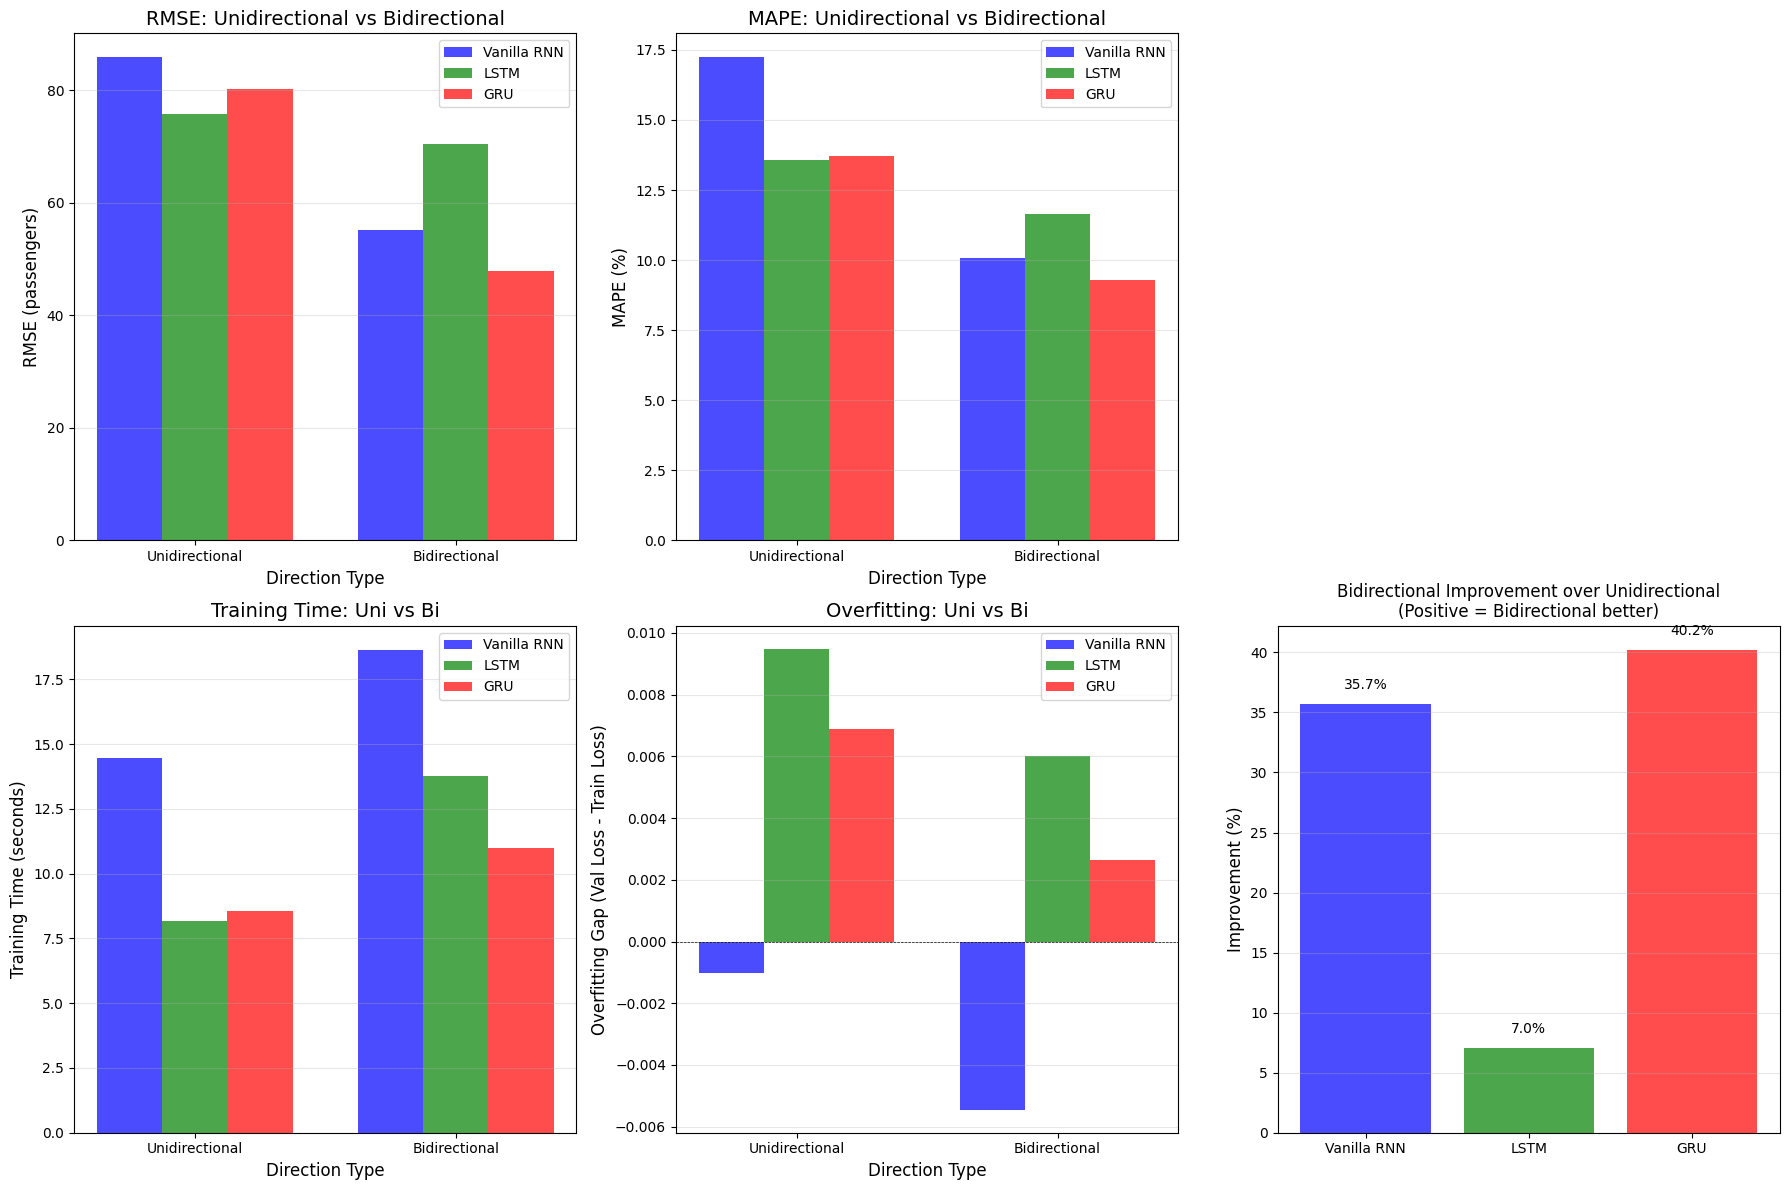


SUMMARY: BIDIRECTIONAL VS UNIDIRECTIONAL ANALYSIS

Model           Direction       RMSE       MAPE       Params       Time(s)    Overfit Gap 
------------------------------------------------------------------------------------------
Vanilla RNN     Unidirectional  85.80      17.23      14.47      -0.0010     
LSTM            Unidirectional  75.77      13.57      8.18       0.0095      
GRU             Unidirectional  80.13      13.72      8.55       0.0069      
Vanilla RNN     Bidirectional   55.17      10.09      18.63      -0.0054     
LSTM            Bidirectional   70.43      11.65      13.75      0.0060      
GRU             Bidirectional   47.91      9.29       11.00      0.0026      


In [21]:
# Analyse the effect of bidirectional RNNs

# Fixed parameters
SEQUENCE_LENGTH = 12
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 32
EPOCHS = 50
DROPOUT_BETWEEN_LAYERS = 0.2  # Fixed dropout
RECURRENT_DROPOUT = 0.0

# Parameters to analyze
bidirectional_options = [False, True]  # False = Unidirectional, True = Bidirectional

# Results storage
results_vrnn_bi = {}
results_lstm_bi = {}
results_gru_bi = {}


# Create sequences
X, y = create_sequences(data_scaled, seq_length=SEQUENCE_LENGTH)
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

for is_bidirectional in bidirectional_options:
    direction_name = "Bidirectional" if is_bidirectional else "Unidirectional"
    print(f"\nTesting: {direction_name} RNN")
    print("-"*40)

    # Create models
    vrnn = create_vanilla_rnn(seq_length=SEQUENCE_LENGTH,
                              hidden_size=HIDDEN_SIZE,
                              num_layers=NUM_LAYERS,
                              dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                              recurrent_dropout=RECURRENT_DROPOUT,
                              bidirectional=is_bidirectional)

    lstm = create_lstm(seq_length=SEQUENCE_LENGTH,
                       hidden_size=HIDDEN_SIZE,
                       num_layers=NUM_LAYERS,
                       dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                       recurrent_dropout=RECURRENT_DROPOUT,
                       bidirectional=is_bidirectional)

    gru = create_gru(seq_length=SEQUENCE_LENGTH,
                     hidden_size=HIDDEN_SIZE,
                     num_layers=NUM_LAYERS,
                     dropout_between_layers=DROPOUT_BETWEEN_LAYERS,
                     recurrent_dropout=RECURRENT_DROPOUT,
                     bidirectional=is_bidirectional)



    # Train Vanilla RNN
    start_time = time.time()
    history_vrnn = vrnn.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                           validation_split=0.1, verbose=0)
    time_vrnn = time.time() - start_time

    # Train LSTM
    start_time = time.time()
    history_lstm = lstm.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                           validation_split=0.1, verbose=0)
    time_lstm = time.time() - start_time

    # Train GRU
    start_time = time.time()
    history_gru = gru.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                         validation_split=0.1, verbose=0)
    time_gru = time.time() - start_time

    # Evaluate
    pred_vrnn, actual, rmse_vrnn, mape_vrnn = evaluate_model(vrnn, X_test, y_test, scaler, "Vanilla RNN")
    pred_lstm, actual, rmse_lstm, mape_lstm = evaluate_model(lstm, X_test, y_test, scaler, "LSTM")
    pred_gru, actual, rmse_gru, mape_gru = evaluate_model(gru, X_test, y_test, scaler, "GRU")

    # Calculate metrics
    train_loss_vrnn = history_vrnn.history['loss'][-1]
    val_loss_vrnn = history_vrnn.history['val_loss'][-1]
    overfitting_gap_vrnn = val_loss_vrnn - train_loss_vrnn

    train_loss_lstm = history_lstm.history['loss'][-1]
    val_loss_lstm = history_lstm.history['val_loss'][-1]
    overfitting_gap_lstm = val_loss_lstm - train_loss_lstm

    train_loss_gru = history_gru.history['loss'][-1]
    val_loss_gru = history_gru.history['val_loss'][-1]
    overfitting_gap_gru = val_loss_gru - train_loss_gru

    # Store results
    results_vrnn_bi[direction_name] = {
        'RMSE': rmse_vrnn,
        'MAPE': mape_vrnn,
        'Training_Time': time_vrnn,
        'Final_Val_Loss': val_loss_vrnn,
        'Overfitting_Gap': overfitting_gap_vrnn
    }

    results_lstm_bi[direction_name] = {
        'RMSE': rmse_lstm,
        'MAPE': mape_lstm,
        'Training_Time': time_lstm,
        'Final_Val_Loss': val_loss_lstm,
        'Overfitting_Gap': overfitting_gap_lstm
    }

    results_gru_bi[direction_name] = {
        'RMSE': rmse_gru,
        'MAPE': mape_gru,
        'Training_Time': time_gru,
        'Final_Val_Loss': val_loss_gru,
        'Overfitting_Gap': overfitting_gap_gru
    }


# Visualization for Bidirectional Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: RMSE Comparison
ax = axes[0, 0]
x_pos = np.arange(len(bidirectional_options))
width = 0.25
ax.bar(x_pos - width, [results_vrnn_bi[d]['RMSE'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='Vanilla RNN', color='blue', alpha=0.7)
ax.bar(x_pos, [results_lstm_bi[d]['RMSE'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='LSTM', color='green', alpha=0.7)
ax.bar(x_pos + width, [results_gru_bi[d]['RMSE'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='GRU', color='red', alpha=0.7)
ax.set_xlabel('Direction Type', fontsize=12)
ax.set_ylabel('RMSE (passengers)', fontsize=12)
ax.set_title('RMSE: Unidirectional vs Bidirectional', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Unidirectional', 'Bidirectional'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: MAPE Comparison
ax = axes[0, 1]
ax.bar(x_pos - width, [results_vrnn_bi[d]['MAPE'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='Vanilla RNN', color='blue', alpha=0.7)
ax.bar(x_pos, [results_lstm_bi[d]['MAPE'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='LSTM', color='green', alpha=0.7)
ax.bar(x_pos + width, [results_gru_bi[d]['MAPE'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='GRU', color='red', alpha=0.7)
ax.set_xlabel('Direction Type', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('MAPE: Unidirectional vs Bidirectional', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Unidirectional', 'Bidirectional'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

axes[0, 2].set_visible(False)

# Plot 4: Training Time Comparison
ax = axes[1, 0]
ax.bar(x_pos - width, [results_vrnn_bi[d]['Training_Time'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='Vanilla RNN', color='blue', alpha=0.7)
ax.bar(x_pos, [results_lstm_bi[d]['Training_Time'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='LSTM', color='green', alpha=0.7)
ax.bar(x_pos + width, [results_gru_bi[d]['Training_Time'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='GRU', color='red', alpha=0.7)
ax.set_xlabel('Direction Type', fontsize=12)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Training Time: Uni vs Bi', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Unidirectional', 'Bidirectional'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 5: Overfitting Gap Comparison
ax = axes[1, 1]
ax.bar(x_pos - width, [results_vrnn_bi[d]['Overfitting_Gap'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='Vanilla RNN', color='blue', alpha=0.7)
ax.bar(x_pos, [results_lstm_bi[d]['Overfitting_Gap'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='LSTM', color='green', alpha=0.7)
ax.bar(x_pos + width, [results_gru_bi[d]['Overfitting_Gap'] for d in ['Unidirectional', 'Bidirectional']],
       width, label='GRU', color='red', alpha=0.7)
ax.set_xlabel('Direction Type', fontsize=12)
ax.set_ylabel('Overfitting Gap (Val Loss - Train Loss)', fontsize=12)
ax.set_title('Overfitting: Uni vs Bi', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Unidirectional', 'Bidirectional'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# Plot 6: Improvement Percentage
ax = axes[1, 2]
improvement_rmse_vrnn = ((results_vrnn_bi['Unidirectional']['RMSE'] - results_vrnn_bi['Bidirectional']['RMSE']) / results_vrnn_bi['Unidirectional']['RMSE']) * 100
improvement_rmse_lstm = ((results_lstm_bi['Unidirectional']['RMSE'] - results_lstm_bi['Bidirectional']['RMSE']) / results_lstm_bi['Unidirectional']['RMSE']) * 100
improvement_rmse_gru = ((results_gru_bi['Unidirectional']['RMSE'] - results_gru_bi['Bidirectional']['RMSE']) / results_gru_bi['Unidirectional']['RMSE']) * 100

models = ['Vanilla RNN', 'LSTM', 'GRU']
improvements = [improvement_rmse_vrnn, improvement_rmse_lstm, improvement_rmse_gru]
colors_bar = ['blue', 'green', 'red']
bars = ax.bar(models, improvements, color=colors_bar, alpha=0.7)
ax.set_ylabel('Improvement (%)', fontsize=12)
ax.set_title('Bidirectional Improvement over Unidirectional\n(Positive = Bidirectional better)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for bar, imp in zip(bars, improvements):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (1 if imp >= 0 else -3),
            f'{imp:.1f}%', ha='center', va='bottom' if imp >= 0 else 'top')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*80)
print("SUMMARY: BIDIRECTIONAL VS UNIDIRECTIONAL ANALYSIS")
print("="*80)

print(f"\n{'Model':<15} {'Direction':<15} {'RMSE':<10} {'MAPE':<10} {'Params':<12} {'Time(s)':<10} {'Overfit Gap':<12}")
print("-"*90)

for direction in ['Unidirectional', 'Bidirectional']:
    print(f"{'Vanilla RNN':<15} {direction:<15} {results_vrnn_bi[direction]['RMSE']:<10.2f} "
          f"{results_vrnn_bi[direction]['MAPE']:<10.2f} "
          f"{results_vrnn_bi[direction]['Training_Time']:<10.2f} "
          f"{results_vrnn_bi[direction]['Overfitting_Gap']:<12.4f}")

    print(f"{'LSTM':<15} {direction:<15} {results_lstm_bi[direction]['RMSE']:<10.2f} "
          f"{results_lstm_bi[direction]['MAPE']:<10.2f} "
          f"{results_lstm_bi[direction]['Training_Time']:<10.2f} "
          f"{results_lstm_bi[direction]['Overfitting_Gap']:<12.4f}")

    print(f"{'GRU':<15} {direction:<15} {results_gru_bi[direction]['RMSE']:<10.2f} "
          f"{results_gru_bi[direction]['MAPE']:<10.2f} "
          f"{results_gru_bi[direction]['Training_Time']:<10.2f} "
          f"{results_gru_bi[direction]['Overfitting_Gap']:<12.4f}")




> In this part we compared unidirectional and bidirectional models, as we can see in all models, the bidirectional RNNs outperform the unidirectional ones, specially it improves alot the performances of GRU and Vanilla models.

5. Dropout Between Recurrent Layers


Testing Dropout Between Layers: 0.0
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 60.15
  Mean Absolute Percentage Error (MAPE): 10.83%

LSTM Results:
  Root Mean Squared Error (RMSE): 79.45
  Mean Absolute Percentage Error (MAPE): 11.73%

GRU Results:
  Root Mean Squared Error (RMSE): 84.13
  Mean Absolute Percentage Error (MAPE): 13.14%

Testing Dropout Between Layers: 0.1
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 65.84
  Mean Absolute Percentage Error (MAPE): 13.07%

LSTM Results:
  Root Mean Squared Error (RMSE): 74.73
  Mean Absolute Percentage Error (MAPE): 13.47%

GRU Results:
  Root Mean Squared Error (RMSE): 80.28
  Mean Absolute Percentage Error (MAPE): 13.42%

Testing Dropout Between Layers: 0.2
----------------------------------------


...


Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 73.39
  Mean Absolute Percentage Error (MAPE): 14.13%

LSTM Results:
  Root Mean Squared Error (RMSE): 80.70
  Mean Absolute Percentage Error (MAPE): 11.48%

GRU Results:
  Root Mean Squared Error (RMSE): 82.68
  Mean Absolute Percentage Error (MAPE): 13.57%

Testing Dropout Between Layers: 0.4
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 96.25
  Mean Absolute Percentage Error (MAPE): 19.08%

LSTM Results:
  Root Mean Squared Error (RMSE): 80.18
  Mean Absolute Percentage Error (MAPE): 11.33%

GRU Results:
  Root Mean Squared Error (RMSE): 83.72
  Mean Absolute Percentage Error (MAPE): 13.38%

Testing Dropout Between Layers: 0.5
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Vanilla RNN Results:
  Root Mean Squared Error (RMSE): 97.10
  Mean Absolute Percentage Error (MAPE): 17.51%

LSTM Results:
  Root Mean Squared Error (RMSE): 73.94
  Mean Absolute Percentage Error (MAPE): 11.80%

GRU Results:
  Root Mean Squared Error (RMSE): 82.28
  Mean Absolute Percentage Error (MAPE): 13.38%


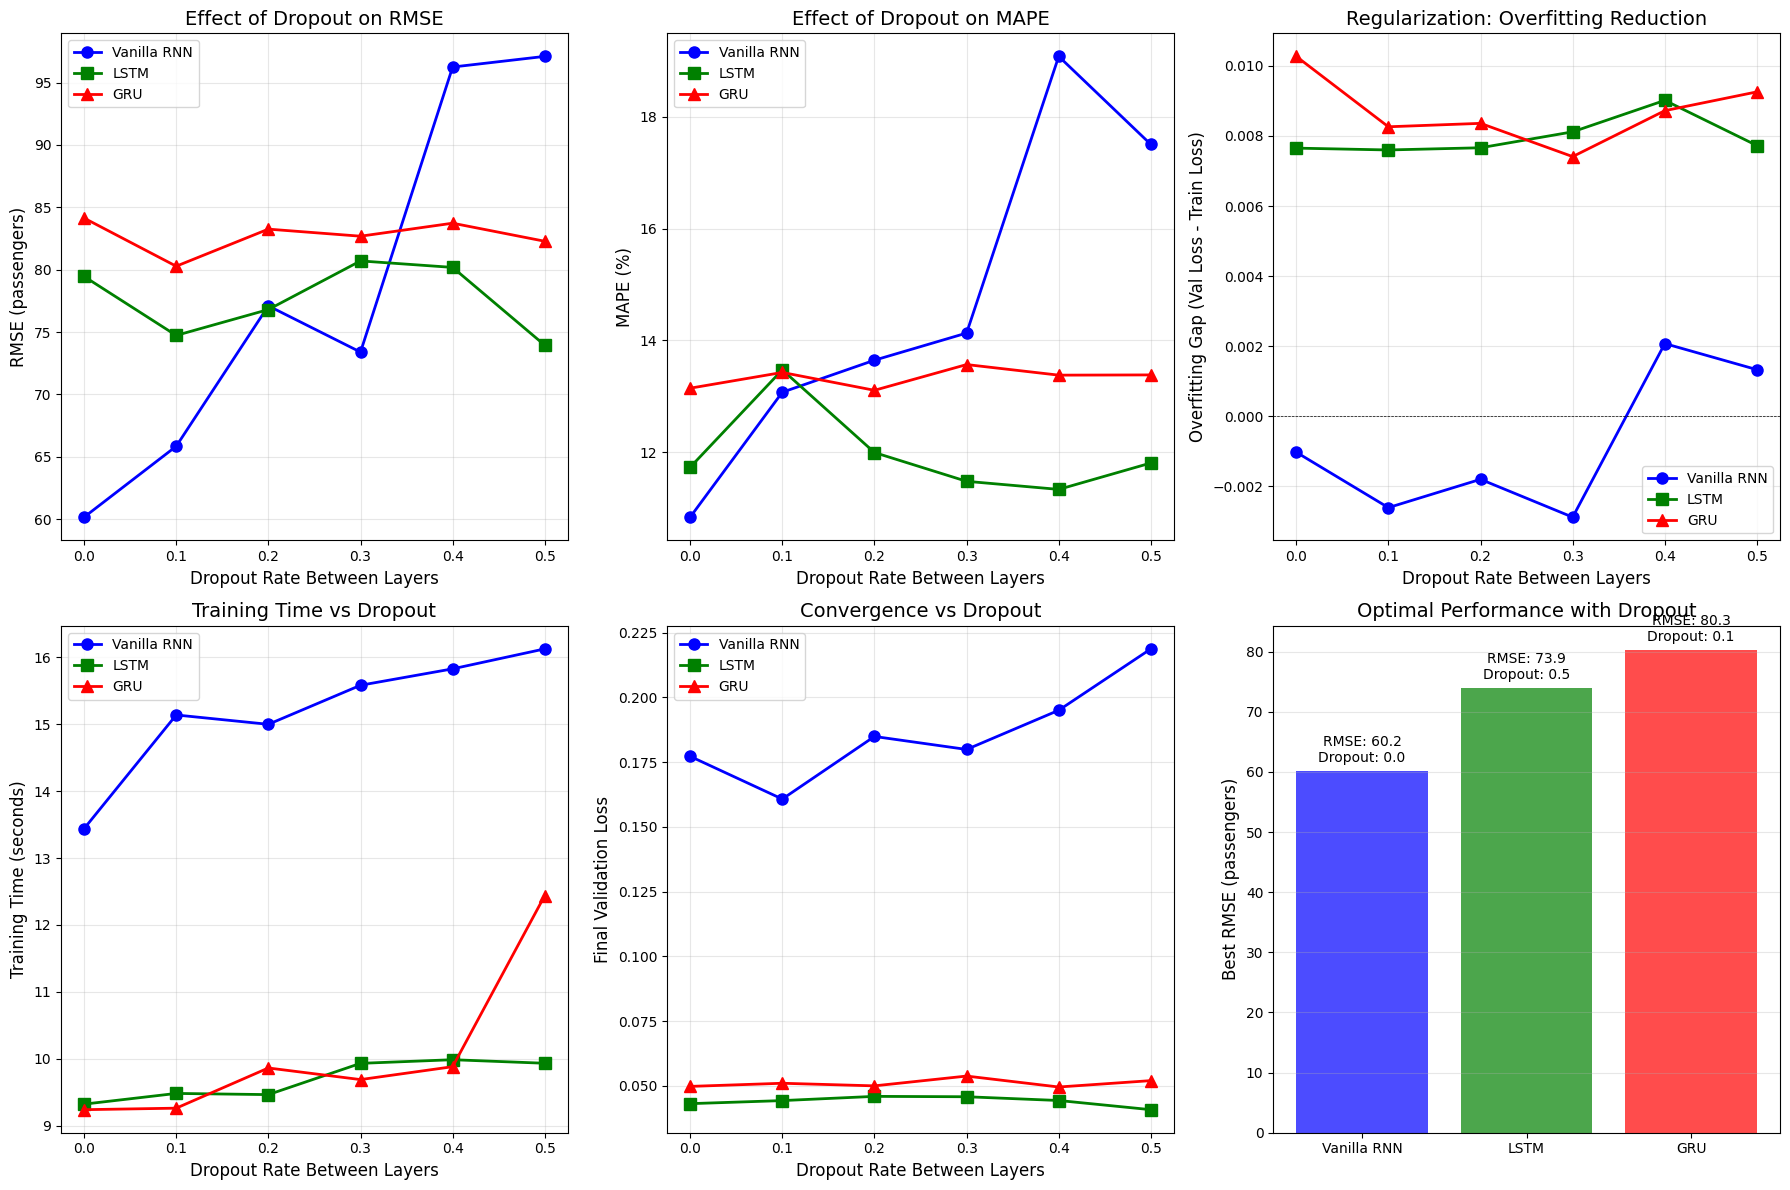


SUMMARY: DROPOUT BETWEEN RECURRENT LAYERS ANALYSIS

Dropout  Model        RMSE       MAPE       Overfit Gap  Time(s)    Val Loss  
--------------------------------------------------------------------------------
0.0      VRNN         60.15      10.83      -0.0010      13.44      0.1772    
0.0      LSTM         79.45      11.73      0.0077       9.32       0.0431    
0.0      GRU          84.13      13.14      0.0103       9.24       0.0497    
--------------------------------------------------------------------------------
0.1      VRNN         65.84      13.07      -0.0026      15.14      0.1608    
0.1      LSTM         74.73      13.47      0.0076       9.48       0.0443    
0.1      GRU          80.28      13.42      0.0083       9.26       0.0509    
--------------------------------------------------------------------------------
0.2      VRNN         77.10      13.64      -0.0018      15.00      0.1849    
0.2      LSTM         76.80      11.99      0.0077       9.46       0.04

In [22]:
# Analyze the effect of Dropout Between Recurrent Layers

# Fixed parameters
SEQUENCE_LENGTH = 12
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 32
EPOCHS = 50
RECURRENT_DROPOUT = 0.0
BIDIRECTIONAL = False  # Fixed to Unidirectional

# Parameters to analyze
dropout_between_options = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

# Results storage
results_vrnn_dropout = {}
results_lstm_dropout = {}
results_gru_dropout = {}


# Create sequences
X, y = create_sequences(data_scaled, seq_length=SEQUENCE_LENGTH)
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

for dropout_rate in dropout_between_options:
    print(f"\nTesting Dropout Between Layers: {dropout_rate}")
    print("-"*40)

    # Create models
    vrnn = create_vanilla_rnn(seq_length=SEQUENCE_LENGTH,
                              hidden_size=HIDDEN_SIZE,
                              num_layers=NUM_LAYERS,
                              dropout_between_layers=dropout_rate,
                              recurrent_dropout=RECURRENT_DROPOUT,
                              bidirectional=BIDIRECTIONAL)

    lstm = create_lstm(seq_length=SEQUENCE_LENGTH,
                       hidden_size=HIDDEN_SIZE,
                       num_layers=NUM_LAYERS,
                       dropout_between_layers=dropout_rate,
                       recurrent_dropout=RECURRENT_DROPOUT,
                       bidirectional=BIDIRECTIONAL)

    gru = create_gru(seq_length=SEQUENCE_LENGTH,
                     hidden_size=HIDDEN_SIZE,
                     num_layers=NUM_LAYERS,
                     dropout_between_layers=dropout_rate,
                     recurrent_dropout=RECURRENT_DROPOUT,
                     bidirectional=BIDIRECTIONAL)

    # Count parameters (should be same for all dropout rates)
    if dropout_rate == dropout_between_options[0]:
        params_vrnn = vrnn.count_params()
        params_lstm = lstm.count_params()
        params_gru = gru.count_params()


    # Train Vanilla RNN
    start_time = time.time()
    history_vrnn = vrnn.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                           validation_split=0.1, verbose=0)
    time_vrnn = time.time() - start_time

    # Train LSTM
    start_time = time.time()
    history_lstm = lstm.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                           validation_split=0.1, verbose=0)
    time_lstm = time.time() - start_time

    # Train GRU
    start_time = time.time()
    history_gru = gru.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                         validation_split=0.1, verbose=0)
    time_gru = time.time() - start_time

    # Evaluate
    pred_vrnn, actual, rmse_vrnn, mape_vrnn = evaluate_model(vrnn, X_test, y_test, scaler, "Vanilla RNN")
    pred_lstm, actual, rmse_lstm, mape_lstm = evaluate_model(lstm, X_test, y_test, scaler, "LSTM")
    pred_gru, actual, rmse_gru, mape_gru = evaluate_model(gru, X_test, y_test, scaler, "GRU")

    # Calculate metrics
    train_loss_vrnn = history_vrnn.history['loss'][-1]
    val_loss_vrnn = history_vrnn.history['val_loss'][-1]
    overfitting_gap_vrnn = val_loss_vrnn - train_loss_vrnn

    train_loss_lstm = history_lstm.history['loss'][-1]
    val_loss_lstm = history_lstm.history['val_loss'][-1]
    overfitting_gap_lstm = val_loss_lstm - train_loss_lstm

    train_loss_gru = history_gru.history['loss'][-1]
    val_loss_gru = history_gru.history['val_loss'][-1]
    overfitting_gap_gru = val_loss_gru - train_loss_gru

    # Store results
    results_vrnn_dropout[dropout_rate] = {
        'RMSE': rmse_vrnn,
        'MAPE': mape_vrnn,
        'Training_Time': time_vrnn,
        'Final_Val_Loss': val_loss_vrnn,
        'Final_Train_Loss': train_loss_vrnn,
        'Overfitting_Gap': overfitting_gap_vrnn
    }

    results_lstm_dropout[dropout_rate] = {
        'RMSE': rmse_lstm,
        'MAPE': mape_lstm,
        'Training_Time': time_lstm,
        'Final_Val_Loss': val_loss_lstm,
        'Final_Train_Loss': train_loss_lstm,
        'Overfitting_Gap': overfitting_gap_lstm
    }

    results_gru_dropout[dropout_rate] = {
        'RMSE': rmse_gru,
        'MAPE': mape_gru,
        'Training_Time': time_gru,
        'Final_Val_Loss': val_loss_gru,
        'Final_Train_Loss': train_loss_gru,
        'Overfitting_Gap': overfitting_gap_gru
    }


# Visualization for Dropout Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: RMSE vs Dropout Rate
ax = axes[0, 0]
ax.plot(dropout_between_options, [results_vrnn_dropout[d]['RMSE'] for d in dropout_between_options],
        'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax.plot(dropout_between_options, [results_lstm_dropout[d]['RMSE'] for d in dropout_between_options],
        's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax.plot(dropout_between_options, [results_gru_dropout[d]['RMSE'] for d in dropout_between_options],
        '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax.set_xlabel('Dropout Rate Between Layers', fontsize=12)
ax.set_ylabel('RMSE (passengers)', fontsize=12)
ax.set_title('Effect of Dropout on RMSE', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: MAPE vs Dropout Rate
ax = axes[0, 1]
ax.plot(dropout_between_options, [results_vrnn_dropout[d]['MAPE'] for d in dropout_between_options],
        'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax.plot(dropout_between_options, [results_lstm_dropout[d]['MAPE'] for d in dropout_between_options],
        's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax.plot(dropout_between_options, [results_gru_dropout[d]['MAPE'] for d in dropout_between_options],
        '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax.set_xlabel('Dropout Rate Between Layers', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('Effect of Dropout on MAPE', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Overfitting Gap vs Dropout Rate
ax = axes[0, 2]
ax.plot(dropout_between_options, [results_vrnn_dropout[d]['Overfitting_Gap'] for d in dropout_between_options],
        'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax.plot(dropout_between_options, [results_lstm_dropout[d]['Overfitting_Gap'] for d in dropout_between_options],
        's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax.plot(dropout_between_options, [results_gru_dropout[d]['Overfitting_Gap'] for d in dropout_between_options],
        '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax.set_xlabel('Dropout Rate Between Layers', fontsize=12)
ax.set_ylabel('Overfitting Gap (Val Loss - Train Loss)', fontsize=12)
ax.set_title('Regularization: Overfitting Reduction', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# Plot 4: Training Time vs Dropout Rate
ax = axes[1, 0]
ax.plot(dropout_between_options, [results_vrnn_dropout[d]['Training_Time'] for d in dropout_between_options],
        'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax.plot(dropout_between_options, [results_lstm_dropout[d]['Training_Time'] for d in dropout_between_options],
        's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax.plot(dropout_between_options, [results_gru_dropout[d]['Training_Time'] for d in dropout_between_options],
        '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax.set_xlabel('Dropout Rate Between Layers', fontsize=12)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Training Time vs Dropout', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 5: Final Validation Loss vs Dropout Rate
ax = axes[1, 1]
ax.plot(dropout_between_options, [results_vrnn_dropout[d]['Final_Val_Loss'] for d in dropout_between_options],
        'o-', linewidth=2, markersize=8, label='Vanilla RNN', color='blue')
ax.plot(dropout_between_options, [results_lstm_dropout[d]['Final_Val_Loss'] for d in dropout_between_options],
        's-', linewidth=2, markersize=8, label='LSTM', color='green')
ax.plot(dropout_between_options, [results_gru_dropout[d]['Final_Val_Loss'] for d in dropout_between_options],
        '^-', linewidth=2, markersize=8, label='GRU', color='red')
ax.set_xlabel('Dropout Rate Between Layers', fontsize=12)
ax.set_ylabel('Final Validation Loss', fontsize=12)
ax.set_title('Convergence vs Dropout', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 6: Optimal Dropout Bar Chart
ax = axes[1, 2]
best_dropout_vrnn = min(results_vrnn_dropout.items(), key=lambda x: x[1]['RMSE'])[0]
best_dropout_lstm = min(results_lstm_dropout.items(), key=lambda x: x[1]['RMSE'])[0]
best_dropout_gru = min(results_gru_dropout.items(), key=lambda x: x[1]['RMSE'])[0]

best_rmse_vrnn = results_vrnn_dropout[best_dropout_vrnn]['RMSE']
best_rmse_lstm = results_lstm_dropout[best_dropout_lstm]['RMSE']
best_rmse_gru = results_gru_dropout[best_dropout_gru]['RMSE']

models = ['Vanilla RNN', 'LSTM', 'GRU']
best_dropouts = [best_dropout_vrnn, best_dropout_lstm, best_dropout_gru]
best_rmses = [best_rmse_vrnn, best_rmse_lstm, best_rmse_gru]
colors_bar = ['blue', 'green', 'red']

bars = ax.bar(models, best_rmses, color=colors_bar, alpha=0.7)
ax.set_ylabel('Best RMSE (passengers)', fontsize=12)
ax.set_title('Optimal Performance with Dropout', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

for bar, dropout, rmse in zip(bars, best_dropouts, best_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'RMSE: {rmse:.1f}\nDropout: {dropout}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*80)
print("SUMMARY: DROPOUT BETWEEN RECURRENT LAYERS ANALYSIS")
print("="*80)

print(f"\n{'Dropout':<8} {'Model':<12} {'RMSE':<10} {'MAPE':<10} {'Overfit Gap':<12} {'Time(s)':<10} {'Val Loss':<10}")
print("-"*80)

for dropout_rate in dropout_between_options:
    print(f"{dropout_rate:<8} {'VRNN':<12} {results_vrnn_dropout[dropout_rate]['RMSE']:<10.2f} "
          f"{results_vrnn_dropout[dropout_rate]['MAPE']:<10.2f} "
          f"{results_vrnn_dropout[dropout_rate]['Overfitting_Gap']:<12.4f} "
          f"{results_vrnn_dropout[dropout_rate]['Training_Time']:<10.2f} "
          f"{results_vrnn_dropout[dropout_rate]['Final_Val_Loss']:<10.4f}")

    print(f"{dropout_rate:<8} {'LSTM':<12} {results_lstm_dropout[dropout_rate]['RMSE']:<10.2f} "
          f"{results_lstm_dropout[dropout_rate]['MAPE']:<10.2f} "
          f"{results_lstm_dropout[dropout_rate]['Overfitting_Gap']:<12.4f} "
          f"{results_lstm_dropout[dropout_rate]['Training_Time']:<10.2f} "
          f"{results_lstm_dropout[dropout_rate]['Final_Val_Loss']:<10.4f}")

    print(f"{dropout_rate:<8} {'GRU':<12} {results_gru_dropout[dropout_rate]['RMSE']:<10.2f} "
          f"{results_gru_dropout[dropout_rate]['MAPE']:<10.2f} "
          f"{results_gru_dropout[dropout_rate]['Overfitting_Gap']:<12.4f} "
          f"{results_gru_dropout[dropout_rate]['Training_Time']:<10.2f} "
          f"{results_gru_dropout[dropout_rate]['Final_Val_Loss']:<10.4f}")
    print("-"*80)

print("\nOPTIMAL DROPOUT RATES:")
print(f"  - Vanilla RNN: {best_dropout_vrnn} (RMSE: {results_vrnn_dropout[best_dropout_vrnn]['RMSE']:.2f})")
print(f"  - LSTM: {best_dropout_lstm} (RMSE: {results_lstm_dropout[best_dropout_lstm]['RMSE']:.2f})")
print(f"  - GRU: {best_dropout_gru} (RMSE: {results_gru_dropout[best_dropout_gru]['RMSE']:.2f})")



> As we can see dropout doesn't help the Vanilla model, but for the LSTM and GRU it helps and based on the RMSE criteria the best rate for each is determined.

# 1. Why LSTMs and GRUs Outperform Vanilla RNNs for Long Sequences

## Why Vanilla RNNs Fail on Long Sequences

A vanilla RNN processes a sequence by maintaining a hidden state that gets updated at each time step:

$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b)$$

During backpropagation through time (BPTT), the gradient of the loss with respect to early time steps involves repeatedly multiplying by the same weight matrix $W_{hh}$.
- If the eigenvalues of $W_{hh}$ are $< 1$ → gradients vanish exponentially (**vanishing gradient problem**)
- If eigenvalues $> 1$ → gradients explode (**exploding gradient problem**)

**Vanishing gradients** mean the network cannot learn long-range dependencies (e.g., remembering a subject from 20 words ago to match a verb). The influence of early inputs decays to near zero.

## How LSTMs and GRUs Solve This

Both LSTMs and GRUs introduce **gated mechanisms** that control the flow of information, allowing the network to decide what to forget, store, and output. This provides paths where gradients can flow unchanged over many time steps.

### LSTMs (Long Short-Term Memory)

LSTM introduces a **cell state** $C_t$ (the "memory") alongside the hidden state $h_t$. Three gates:

1. **Forget gate**:
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
Decides what to discard from the previous cell state. Values near $0$ → forget; near $1$ → keep.

2. **Input gate**:
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
Decides which new information to store.

3. **Candidate cell state**:
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$
New candidate values to add.

4. **Output gate**:
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
Controls what parts of the cell state go to the hidden state.

**Cell state update**:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

The key: if the forget gate $f_t$ is near $1$ for many steps, the gradient can flow through the **identity mapping** $C_{t-1} \to C_t$, bypassing nonlinearities that cause vanishing gradients.

### GRUs (Gated Recurrent Units)

GRU simplifies LSTM by combining forget and input gates into a single **update gate**, and merging cell state with hidden state.

1. **Update gate**:
$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$
Decides how much of the previous hidden state to keep.

2. **Reset gate**:
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$
Decides how much of the previous state to ignore when computing new candidate.

3. **Candidate hidden state**:
$$\tilde{h}_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t])$$

4. **Final hidden state**:
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

Here, if $z_t$ is small, $h_t \approx h_{t-1}$ — again, a path for gradient flow without decay.

## 2. The Role of Gates in Solving Vanishing Gradients

| Mechanism | Effect on Gradients |
|-----------|---------------------|
| **Forget gate (LSTM)** / **Update gate (GRU)** | Allows the network to learn to keep gradients at $\sim 1$ over many steps by setting $f_t \approx 1$ or $z_t \approx 0$. Creates a **highway path** for backpropagation. |
| **Reset gate (GRU)** / **Input gate (LSTM)** | Lets the network discard irrelevant history, preventing gradient noise from irrelevant past states. |
| **Additive updates** (instead of multiplicative in vanilla RNN) | Vanilla RNN: $h_t = \tanh(W h_{t-1} + \dots)$ → gradient has $\prod \tanh'(\cdot) W$, which shrinks. LSTM/GRU: additive structure with gating means the gradient can pass through the "copy" path without repeated compression. |

Concretely, in backprop, the derivative:

$$\frac{\partial C_t}{\partial C_{t-1}} = \text{diag}(f_t)$$

(ignoring the second term's dependence). If the network learns $f_t \approx 1$ for many steps, the gradient norm doesn't vanish.

## Why Not Just Use Skip Connections?

Skip connections (ResNets) help deep feedforward networks but aren't adaptive. LSTMs/GRUs **learn** which time steps to remember and which to forget, based on the input data itself. This is crucial for sequences with varying lengths of dependency (e.g., in language: sometimes you need to remember a noun for 2 words, sometimes for 20).